In [1]:
#!pip install pandas openpyxl

In [2]:
import pandas as pd
import glob
import os
import csv
import numpy as np
from scipy.stats import mannwhitneyu
import datetime as dt
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Caminho da pasta com os CSVs (ajustar se necessário)
PASTA = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Oficina de Escrita Científica\Artigo\Planilhas do Portal da Transparência\Planilhas de Licitação de todos os meses"

# Colunas que serão mantidas
COLUNAS = [
    "Número Licitação",
    "Modalidade Compra",
    "UF",
    "Data Resultado Compra",
    "Data Abertura",
    "Valor Licitação",
]

# Tentativas para lidar com separador e encoding desconhecidos
ENCODINGS = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
SEPARADORES = [";", ",", "\t", "|"]

def ler_csv_flexivel(arquivo: str) -> pd.DataFrame:
    ultimo_erro = None
    for enc in ENCODINGS:
        for sep in SEPARADORES:
            try:
                df = pd.read_csv(
                    arquivo,
                    sep=sep,
                    encoding=enc,
                    engine="python",
                    dtype={
                        "Número Licitação": "string",
                        "Modalidade Compra": "string",
                        "UF": "string",
                        "Data Resultado Compra": "string",
                        "Data Abertura": "string",
                        "Valor Licitação": "string",
                    },
                )
                # Critério forte: só aceita se TODAS as colunas desejadas existirem
                if all(c in df.columns for c in COLUNAS):
                    return df
            except Exception as e:
                ultimo_erro = e
                continue

    raise RuntimeError(f"Falha ao ler '{os.path.basename(arquivo)}'. Último erro: {ultimo_erro}")

# Listar arquivos CSV
arquivos = sorted(glob.glob(os.path.join(PASTA, "*.csv")))
print(f"Arquivos encontrados: {len(arquivos)}")
if not arquivos:
    raise FileNotFoundError(f"Nenhum CSV encontrado em: {PASTA}")

# Ler e consolidar
dfs = []
erros = []

for arq in arquivos:
    try:
        df = ler_csv_flexivel(arq)
        df = df[COLUNAS].copy()
        df["__arquivo_origem"] = os.path.basename(arq)  # rastreabilidade (você pode remover depois)
        dfs.append(df)
    except Exception as e:
        erros.append((os.path.basename(arq), str(e)))

df_final = pd.concat(dfs, ignore_index=True)

print("Consolidação concluída.")
print("Linhas:", len(df_final), "| Colunas:", df_final.shape[1])
print("Arquivos com erro:", len(erros))
if erros:
    display(pd.DataFrame(erros, columns=["arquivo", "erro"]))


Arquivos encontrados: 64
Consolidação concluída.
Linhas: 636961 | Colunas: 7
Arquivos com erro: 0


In [4]:
# Converter datas (tenta interpretar automaticamente)
df_final["Data Resultado Compra"] = pd.to_datetime(df_final["Data Resultado Compra"], errors="coerce", dayfirst=True)
df_final["Data Abertura"] = pd.to_datetime(df_final["Data Abertura"], errors="coerce", dayfirst=True)

# Converter Valor Licitação (remove separadores e converte)
# Ajuste abaixo se seus valores vierem como "1.234,56" (padrão BR)
valor = df_final["Valor Licitação"].astype("string").str.strip()
valor = valor.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
df_final["Valor Licitação"] = pd.to_numeric(valor, errors="coerce")

df_final.head()


,Número Licitação,Modalidade Compra,UF,Data Resultado Compra,Data Abertura,Valor Licitação,__arquivo_origem
0,000012017,Tomada de Preços,RJ,2019-01-17,NaT,564266.95,201901_Licitação.csv
1,000012017,Inexigibilidade de Licitação,RJ,2019-01-23,NaT,5567.2,201901_Licitação.csv
2,000012018,Dispensa de Licitação,-3,2019-01-02,NaT,6200.0,201901_Licitação.csv
3,000012018,Pregão - Registro de Preço,DF,2019-01-02,2018-12-31,85975.6,201901_Licitação.csv
4,000012018,Inexigibilidade de Licitação,MG,2019-01-22,NaT,3400.0,201901_Licitação.csv


In [5]:
# Garantir que as colunas de data são datetime
df_final["Data Resultado Compra"] = pd.to_datetime(df_final["Data Resultado Compra"], errors="coerce", dayfirst=True)
df_final["Data Abertura"] = pd.to_datetime(df_final["Data Abertura"], errors="coerce", dayfirst=True)

# ======================================================
# Aqui eu removo do PORTAL DA TRANSPARÊNCIA as observações de 2024+
# para reduzir risco de sobreposição com o PNCP (Lei 14.133 já obrigatória).
# Eu uso a Data Abertura como referência temporal.
# Eu removo apenas quando a Data Abertura é válida (não-NaT),
# para não misturar esse corte com perdas por dado faltante.
# ======================================================

antes_portal_2024 = len(df_final)

mask_data_valida = df_final["Data Abertura"].notna()
mask_2024_mais = df_final["Data Abertura"] >= "2024-01-01"

df_final = df_final[~(mask_data_valida & mask_2024_mais)].copy()

depois_portal_2024 = len(df_final)

print("Linhas antes de remover Portal 2024+: ", antes_portal_2024)
print("Linhas depois de remover Portal 2024+: ", depois_portal_2024)
print("Linhas removidas (Portal 2024+): ", antes_portal_2024 - depois_portal_2024)


Linhas antes de remover Portal 2024+:  636961
Linhas depois de remover Portal 2024+:  633351
Linhas removidas (Portal 2024+):  3610


In [6]:
print("\n--- INFORMAÇÕES GERAIS ---")
df_final.info()



--- INFORMAÇÕES GERAIS ---
<class 'pandas.DataFrame'>
Index: 633351 entries, 0 to 636959
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Número Licitação       633351 non-null  string        
 1   Modalidade Compra      633351 non-null  string        
 2   UF                     633351 non-null  string        
 3   Data Resultado Compra  633351 non-null  datetime64[us]
 4   Data Abertura          193257 non-null  datetime64[us]
 5   Valor Licitação        633351 non-null  Float64       
 6   __arquivo_origem       633351 non-null  str           
dtypes: Float64(1), datetime64[us](2), str(1), string(3)
memory usage: 39.3 MB


In [7]:
licitacoes_por_estado = (
    df_final
        .groupby("UF", observed=True)
        .size()
        .sort_values(ascending=False)
)

print(licitacoes_por_estado)

UF
RJ    132557
RS     70645
MG     59750
DF     56122
SP     40446
PR     32567
SC     25380
PA     22864
BA     22403
PE     20961
MS     16656
AM     15948
GO     12709
RN     12403
CE     12278
PB     11460
MT     10752
ES     10221
RO      7130
MA      6668
PI      5840
-3      5725
AL      4553
SE      4455
AC      3485
RR      3259
TO      3240
AP      2874
dtype: int64


## Alterei abaixo, na planlilha do portal tem uma UF nomeada com -3, percebi que são orgão do DF então alterei ela para DF

In [8]:
# 1. Correção do dado
df_final['UF'] = df_final['UF'].replace('-3', 'DF')

# 2. Agrupamento (o mesmo que você já fez)
licitacoes_por_estado = (
    df_final
        .groupby("UF", observed=True)
        .size()
        .sort_values(ascending=False)
)

print(licitacoes_por_estado)

UF
RJ    132557
RS     70645
DF     61847
MG     59750
SP     40446
PR     32567
SC     25380
PA     22864
BA     22403
PE     20961
MS     16656
AM     15948
GO     12709
RN     12403
CE     12278
PB     11460
MT     10752
ES     10221
RO      7130
MA      6668
PI      5840
AL      4553
SE      4455
AC      3485
RR      3259
TO      3240
AP      2874
dtype: int64


In [9]:
# 1) Remover linhas com datas faltantes (NaT) – requisito para calcular celeridade
df_limpo = df_final.dropna(subset=["Data Resultado Compra", "Data Abertura"]).copy()

# 2) Manter apenas UFs válidas (2 letras)
df_limpo["UF"] = df_limpo["UF"].astype("string").str.strip().str.upper()
df_limpo = df_limpo[df_limpo["UF"].str.fullmatch(r"[A-Z]{2}", na=False)].copy()

# 3) Remover valores faltantes ou não positivos
df_limpo = df_limpo.dropna(subset=["Valor Licitação"])
df_limpo = df_limpo[df_limpo["Valor Licitação"] > 0].copy()

print("Antes:", len(df_final))
print("Depois:", len(df_limpo))
df_limpo.head()

Antes: 633351
Depois: 163428


,Número Licitação,Modalidade Compra,UF,Data Resultado Compra,Data Abertura,Valor Licitação,__arquivo_origem
3,000012018,Pregão - Registro de Preço,DF,2019-01-02,2018-12-31,85975.6,201901_Licitação.csv
5,000012018,Pregão,RJ,2019-01-16,2018-12-14,117999.99,201901_Licitação.csv
6,000012018,Pregão - Registro de Preço,MS,2019-01-15,2018-11-23,5659.2,201901_Licitação.csv
15,000012018,Pregão - Registro de Preço,DF,2019-01-17,2018-12-04,1745071.34,201901_Licitação.csv
18,000012018,Pregão - Registro de Preço,PA,2019-01-03,2018-11-08,1392.0,201901_Licitação.csv


In [10]:
# 1) Renomear coluna de origem
df_limpo = df_limpo.rename(columns={"__arquivo_origem": "Arquivo_Origem"})

# 2) Definir nova ordem das colunas
nova_ordem = [
    "Número Licitação",
    "Modalidade Compra",
    "UF",
    "Data Abertura",
    "Data Resultado Compra",
    "Valor Licitação",
    "Arquivo_Origem"
]

df_limpo = df_limpo[nova_ordem]

# Conferir resultado
df_limpo.head()

,Número Licitação,Modalidade Compra,UF,Data Abertura,Data Resultado Compra,Valor Licitação,Arquivo_Origem
3,000012018,Pregão - Registro de Preço,DF,2018-12-31,2019-01-02,85975.6,201901_Licitação.csv
5,000012018,Pregão,RJ,2018-12-14,2019-01-16,117999.99,201901_Licitação.csv
6,000012018,Pregão - Registro de Preço,MS,2018-11-23,2019-01-15,5659.2,201901_Licitação.csv
15,000012018,Pregão - Registro de Preço,DF,2018-12-04,2019-01-17,1745071.34,201901_Licitação.csv
18,000012018,Pregão - Registro de Preço,PA,2018-11-08,2019-01-03,1392.0,201901_Licitação.csv


In [ ]:
# Aqui eu defino o caminho da pasta do PNCP
PASTA_PNCP = r"C:\Users\rafae\OneDrive\Documentos\Mestrado IDP\Matérias\Oficina de Escrita Científica\Artigo\Planilhas do PNCP\2_Planilhas PNCP\Planilhas PNCP"

# Aqui eu separo arquivos de compra e de resultado
arquivos_compra = sorted(glob.glob(os.path.join(PASTA_PNCP, "*COMPRA*.csv")))
arquivos_resultado = sorted(glob.glob(os.path.join(PASTA_PNCP, "*ITEM_RESULTADO*.csv")))

print("Arquivos de COMPRA:")
print(arquivos_compra)

print("\nArquivos de RESULTADO:")
print(arquivos_resultado)

Arquivos de COMPRA:
['C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-COMPRA-2021.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-COMPRA-2022.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-COMPRA-2023.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-COMPRA-2024.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-COMPRA-2025.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-ITEM_RESULTADO-2021.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-ITEM_RESULTADO-2022.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-ITEM_RESULTADO-2023.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\comprasGOV-ITEM_RESULTADO-2024.csv', 'C:\\Users\\rafaelcs\\Documents\\Artigo Licitação\\Planilhas\\PNCP\\compra

In [15]:
# Aqui eu inspeciono o cabeçalho de cada arquivo COMPRA para descobrir como a coluna de "data_inclusao" aparece em cada ano
for arq in arquivos_compra:
    cab = pd.read_csv(arq, sep=",", encoding="utf-8", nrows=0)
    cols_data = [c for c in cab.columns if "data" in c.lower()]
    print("\nArquivo:", os.path.basename(arq))
    print("Colunas com 'data':", cols_data)



Arquivo: comprasGOV-COMPRA-2021.csv
Colunas com 'data': ['data_atualizacao', 'data_publicacao_pncp', 'data_inclusao', 'data_abertura_proposta', 'data_encerramento_proposta']

Arquivo: comprasGOV-COMPRA-2022.csv
Colunas com 'data': ['data_atualizacao', 'data_publicacao_pncp', 'data_inclusao', 'data_abertura_proposta', 'data_encerramento_proposta']

Arquivo: comprasGOV-COMPRA-2023.csv
Colunas com 'data': ['data_atualizacao', 'data_publicacao_pncp', 'data_inclusao', 'data_abertura_proposta', 'data_encerramento_proposta']

Arquivo: comprasGOV-COMPRA-2024.csv
Colunas com 'data': ['data_atualizacao', 'data_publicacao_pncp', 'data_inclusao', 'data_abertura_proposta', 'data_encerramento_proposta']

Arquivo: comprasGOV-COMPRA-2025.csv
Colunas com 'data': ['data_atualizacao_pncp', 'data_publicacao_pncp', 'data_inclusao_pncp', 'data_abertura_proposta_pncp', 'data_encerramento_proposta_pncp']

Arquivo: comprasGOV-ITEM_RESULTADO-2021.csv
Colunas com 'data': ['data_atualizacao', 'data_inclusao', 'd

In [16]:
# ---------------------------
# 1) Aqui eu defino funções utilitárias para ler só o necessário e padronizar nomes
# ---------------------------

def ler_colunas_existentes(arquivo, colunas_desejadas):
    """
    Aqui eu leio apenas as colunas que realmente existem no arquivo,
    evitando erro de usecols quando algum ano muda o nome da coluna.
    """
    cab = pd.read_csv(arquivo, sep=",", encoding="utf-8", nrows=0)
    existentes = [c for c in colunas_desejadas if c in cab.columns]
    return pd.read_csv(arquivo, sep=",", encoding="utf-8", engine="c", usecols=existentes)

def padronizar_coluna(df, possiveis, nome_padrao):
    """
    Aqui eu padronizo um nome de coluna.
    Se eu encontrar a primeira opção existente, eu renomeio para o nome_padrao.
    """
    for c in possiveis:
        if c in df.columns:
            return df.rename(columns={c: nome_padrao})
    return df  # se não encontrar, devolvo como está

# ---------------------------
# 2) Aqui eu carrego e consolido os arquivos COMPRA
# ---------------------------

COLS_COMPRA_DESEJADAS = [
    "id_compra",
    "modalidade_nome",
    "unidade_orgao_uf_sigla",
    "data_inclusao",
    "data_inclusao_pncp",
    "valor_total_homologado",
    "contratacao_excluida",
]

lista_compra = []
print("Iniciando leitura dos arquivos COMPRA (2021–2025)...")

for i, arquivo in enumerate(arquivos_compra, start=1):
    print(f"Lendo COMPRA ({i}/{len(arquivos_compra)}): {os.path.basename(arquivo)}")
    df_temp = ler_colunas_existentes(arquivo, COLS_COMPRA_DESEJADAS)

    # Aqui eu padronizo a data de início do processo no PNCP (opção B que você escolheu)
    df_temp = padronizar_coluna(df_temp, ["data_inclusao", "data_inclusao_pncp"], "Data_Abertura")

    # Aqui eu adiciono rastreabilidade do arquivo
    df_temp["Arquivo_Origem"] = os.path.basename(arquivo)

    lista_compra.append(df_temp)

pncp_compra = pd.concat(lista_compra, ignore_index=True)

# Aqui eu excluo contratações marcadas como excluídas no PNCP
pncp_compra["contratacao_excluida"] = pncp_compra["contratacao_excluida"].astype("string").str.strip().str.upper()
pncp_compra = pncp_compra[pncp_compra["contratacao_excluida"] != "VERDADEIRO"].copy()

print("COMPRA consolidado:", pncp_compra.shape)

# ---------------------------
# 3) Aqui eu carrego e consolido os arquivos ITEM_RESULTADO
# ---------------------------

COLS_RESULTADO_DESEJADAS = [
    "id_compra",
    "data_resultado",
    "data_resultado_pncp",
]

lista_resultado = []
print("\nIniciando leitura dos arquivos ITEM_RESULTADO (2021–2025)...")

for i, arquivo in enumerate(arquivos_resultado, start=1):
    print(f"Lendo ITEM_RESULTADO ({i}/{len(arquivos_resultado)}): {os.path.basename(arquivo)}")
    df_temp = ler_colunas_existentes(arquivo, COLS_RESULTADO_DESEJADAS)

    # Aqui eu padronizo a data de resultado (fim) no PNCP
    df_temp = padronizar_coluna(df_temp, ["data_resultado", "data_resultado_pncp"], "Data_Resultado")

    # Aqui eu adiciono rastreabilidade do arquivo
    df_temp["Arquivo_Origem_Item"] = os.path.basename(arquivo)

    lista_resultado.append(df_temp)

pncp_resultado_itens = pd.concat(lista_resultado, ignore_index=True)
print("ITEM_RESULTADO (itens) consolidado:", pncp_resultado_itens.shape)

# ---------------------------
# 4) Aqui eu consolido por id_compra usando a ÚLTIMA data de resultado (max)
# ---------------------------

# Aqui eu converto datas para datetime (para o max funcionar corretamente)
pncp_resultado_itens["Data_Resultado"] = pd.to_datetime(pncp_resultado_itens["Data_Resultado"], errors="coerce")

pncp_resultado = (
    pncp_resultado_itens
    .dropna(subset=["id_compra", "Data_Resultado"])
    .groupby("id_compra", as_index=False)["Data_Resultado"]
    .max()
)

print("ITEM_RESULTADO consolidado por id_compra:", pncp_resultado.shape)

# ---------------------------
# 5) Aqui eu faço o merge final: uma linha por compra/contratação
# ---------------------------

pncp_final = pncp_compra.merge(pncp_resultado, on="id_compra", how="left")

# Aqui eu converto Data_Abertura para datetime e mantenho Data_Resultado já em datetime
pncp_final["Data_Abertura"] = pd.to_datetime(pncp_final["Data_Abertura"], errors="coerce")

print("\nPNCP final (após merge):", pncp_final.shape)
pncp_final.head(5)


Iniciando leitura dos arquivos COMPRA (2021–2025)...
Lendo COMPRA (1/10): comprasGOV-COMPRA-2021.csv
Lendo COMPRA (2/10): comprasGOV-COMPRA-2022.csv
Lendo COMPRA (3/10): comprasGOV-COMPRA-2023.csv
Lendo COMPRA (4/10): comprasGOV-COMPRA-2024.csv


C:\Users\rafaelcs\AppData\Local\Temp\ipykernel_34116\716243310.py:12: DtypeWarning: Columns (0: data_inclusao) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(arquivo, sep=",", encoding="utf-8", engine="c", usecols=existentes)


Lendo COMPRA (5/10): comprasGOV-COMPRA-2025.csv
Lendo COMPRA (6/10): comprasGOV-ITEM_RESULTADO-2021.csv
Lendo COMPRA (7/10): comprasGOV-ITEM_RESULTADO-2022.csv
Lendo COMPRA (8/10): comprasGOV-ITEM_RESULTADO-2023.csv
Lendo COMPRA (9/10): comprasGOV-ITEM_RESULTADO-2024.csv
Lendo COMPRA (10/10): comprasGOV-ITEM_RESULTADO-2025.csv
COMPRA consolidado: (775854, 7)

Iniciando leitura dos arquivos ITEM_RESULTADO (2021–2025)...
Lendo ITEM_RESULTADO (1/5): comprasGOV-ITEM_RESULTADO-2021.csv
Lendo ITEM_RESULTADO (2/5): comprasGOV-ITEM_RESULTADO-2022.csv
Lendo ITEM_RESULTADO (3/5): comprasGOV-ITEM_RESULTADO-2023.csv


C:\Users\rafaelcs\AppData\Local\Temp\ipykernel_34116\716243310.py:12: DtypeWarning: Columns (0: data_resultado) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(arquivo, sep=",", encoding="utf-8", engine="c", usecols=existentes)


Lendo ITEM_RESULTADO (4/5): comprasGOV-ITEM_RESULTADO-2024.csv
Lendo ITEM_RESULTADO (5/5): comprasGOV-ITEM_RESULTADO-2025.csv
ITEM_RESULTADO (itens) consolidado: (5025991, 3)
ITEM_RESULTADO consolidado por id_compra: (706163, 2)

PNCP final (após merge): (775854, 8)


,id_compra,valor_total_homologado,unidade_orgao_uf_sigla,Data_Abertura,modalidade_nome,contratacao_excluida,Arquivo_Origem,Data_Resultado
0,16001906000222021,NaN,AM,2021-12-06 07:00:38,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,NaT
1,7001206000282021,NaN,SE,2021-09-16 13:07:17,Dispensa,TRUE,comprasGOV-COMPRA-2021.csv,NaT
2,7001206000252021,NaN,SE,2021-09-16 15:42:14,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,NaT
3,15328406000042021,NaN,MG,2021-08-13 07:00:19,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,NaT
4,12063106000832021,NaN,RN,2021-12-09 07:01:07,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,NaT


In [17]:
# Aqui eu padronizo a coluna contratacao_excluida para texto em maiúsculas
pncp_final["contratacao_excluida"] = pncp_final["contratacao_excluida"].astype("string").str.strip().str.upper()

# Aqui eu removo contratações excluídas, seja no padrão brasileiro (VERDADEIRO) ou inglês (TRUE)
pncp_final = pncp_final[~pncp_final["contratacao_excluida"].isin(["VERDADEIRO", "TRUE"])].copy()

# Aqui eu verifico quantas linhas ficaram e qual a proporção que tem Data_Resultado preenchida
total = len(pncp_final)
com_resultado = pncp_final["Data_Resultado"].notna().sum()
sem_resultado = pncp_final["Data_Resultado"].isna().sum()

print("Linhas após remover excluídas:", total)
print("Com Data_Resultado:", com_resultado, f"({com_resultado/total:.1%})")
print("Sem Data_Resultado:", sem_resultado, f"({sem_resultado/total:.1%})")


Linhas após remover excluídas: 773032
Com Data_Resultado: 622302 (80.5%)
Sem Data_Resultado: 150730 (19.5%)


In [18]:
licitacoes_por_estado_pncp = (
    pncp_final
        .groupby("unidade_orgao_uf_sigla", observed=True)
        .size()
        .sort_values(ascending=False)
)

print(licitacoes_por_estado_pncp)

unidade_orgao_uf_sigla
SP    191177
RJ    111429
PR     61739
DF     52746
MG     50298
RS     43450
PE     24363
BA     22254
PA     20169
ES     18515
SC     18050
CE     16008
PB     15428
RN     14959
GO     14198
AM     13467
RO     12883
MS     11758
MT      8970
AL      8969
PI      8535
MA      7831
TO      7815
AC      4965
RR      4958
SE      4412
AP      3686
dtype: int64


In [19]:
# Aqui eu mantenho apenas as contratações que possuem Data_Abertura e Data_Resultado,
# pois somente com ambas posso calcular a duração do processo

pncp_analitico = pncp_final.dropna(subset=["Data_Abertura", "Data_Resultado"]).copy()

print("Base analítica PNCP:")
print("Linhas:", len(pncp_analitico))

Base analítica PNCP:
Linhas: 622302


In [20]:
# ======================================================
# LIMPEZA DO PNCP (espelhando o protocolo do Portal)
# ======================================================

# 1) Garantir que as colunas de data são datetime
pncp_analitico["Data_Abertura"] = pd.to_datetime(
    pncp_analitico["Data_Abertura"], errors="coerce"
)

pncp_analitico["Data_Resultado"] = pd.to_datetime(
    pncp_analitico["Data_Resultado"], errors="coerce"
)

# 2) Remover linhas com datas faltantes
pncp_limpo = pncp_analitico.dropna(
    subset=["Data_Abertura", "Data_Resultado"]
).copy()

# 3) Padronizar UF (duas letras maiúsculas)
pncp_limpo["unidade_orgao_uf_sigla"] = (
    pncp_limpo["unidade_orgao_uf_sigla"]
    .astype("string")
    .str.strip()
    .str.upper()
)

pncp_limpo = pncp_limpo[
    pncp_limpo["unidade_orgao_uf_sigla"].str.fullmatch(r"[A-Z]{2}", na=False)
].copy()

# 4) Converter valor para numérico (garantindo coerência)
pncp_limpo["valor_total_homologado"] = pd.to_numeric(
    pncp_limpo["valor_total_homologado"],
    errors="coerce"
)

pncp_limpo = pncp_limpo.dropna(subset=["valor_total_homologado"]).copy()
pncp_limpo = pncp_limpo[pncp_limpo["valor_total_homologado"] > 0].copy()

# ======================================================
# Verificação final da limpeza
# ======================================================

print("Antes da limpeza:", len(pncp_final))
print("Após remover excluídas e sem resultado:", len(pncp_analitico))
print("Após limpeza final:", len(pncp_limpo))

pncp_limpo.head()


Antes da limpeza: 773032
Após remover excluídas e sem resultado: 622302
Após limpeza final: 614883


,id_compra,valor_total_homologado,unidade_orgao_uf_sigla,Data_Abertura,modalidade_nome,contratacao_excluida,Arquivo_Origem,Data_Resultado
2941,20010006000062021,15130.00,DF,2021-09-24 07:00:12,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,2021-10-26
2942,16021706002172021,1770.55,PR,2021-11-26 12:32:28,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,2021-11-26
2943,15328006000162021,3478.26,MG,2021-11-08 07:00:31,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,2021-11-22
2944,11460706000022021,14060.50,AP,2021-10-04 07:00:09,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,2021-10-20
2945,15590306000802021,4849.04,MG,2021-10-21 07:00:55,Dispensa,FALSE,comprasGOV-COMPRA-2021.csv,2021-12-02


In [21]:
# ======================================================
# PADRONIZAÇÃO DO PNCP PARA ESTRUTURA NEUTRA
# ======================================================

pncp_padronizado = pncp_limpo.rename(columns={
    "id_compra": "id_licitacao",
    "modalidade_nome": "modalidade",
    "unidade_orgao_uf_sigla": "uf",
    "Data_Abertura": "data_abertura",
    "Data_Resultado": "data_resultado",
    "valor_total_homologado": "valor_licitacao",
    "Arquivo_Origem": "arquivo_origem"
})

# Aqui eu seleciono apenas as colunas que farão parte da base harmonizada
pncp_padronizado = pncp_padronizado[
    [
        "id_licitacao",
        "modalidade",
        "uf",
        "data_abertura",
        "data_resultado",
        "valor_licitacao",
        "arquivo_origem",
    ]
].copy()

print("PNCP padronizado:", pncp_padronizado.shape)
pncp_padronizado.head()


PNCP padronizado: (614883, 7)


,id_licitacao,modalidade,uf,data_abertura,data_resultado,valor_licitacao,arquivo_origem
2941,20010006000062021,Dispensa,DF,2021-09-24 07:00:12,2021-10-26,15130.00,comprasGOV-COMPRA-2021.csv
2942,16021706002172021,Dispensa,PR,2021-11-26 12:32:28,2021-11-26,1770.55,comprasGOV-COMPRA-2021.csv
2943,15328006000162021,Dispensa,MG,2021-11-08 07:00:31,2021-11-22,3478.26,comprasGOV-COMPRA-2021.csv
2944,11460706000022021,Dispensa,AP,2021-10-04 07:00:09,2021-10-20,14060.50,comprasGOV-COMPRA-2021.csv
2945,15590306000802021,Dispensa,MG,2021-10-21 07:00:55,2021-12-02,4849.04,comprasGOV-COMPRA-2021.csv


In [22]:
# ======================================================
# PADRONIZAÇÃO DO PORTAL PARA ESTRUTURA NEUTRA
# ======================================================

portal_padronizado = df_limpo.rename(columns={
    "Número Licitação": "id_licitacao",
    "Modalidade Compra": "modalidade",
    "UF": "uf",
    "Data Abertura": "data_abertura",
    "Data Resultado Compra": "data_resultado",
    "Valor Licitação": "valor_licitacao",
    "Arquivo_Origem": "arquivo_origem"
})

portal_padronizado = portal_padronizado[
    [
        "id_licitacao",
        "modalidade",
        "uf",
        "data_abertura",
        "data_resultado",
        "valor_licitacao",
        "arquivo_origem",
    ]
].copy()

print("Portal padronizado:", portal_padronizado.shape)
portal_padronizado.head()


Portal padronizado: (163428, 7)


,id_licitacao,modalidade,uf,data_abertura,data_resultado,valor_licitacao,arquivo_origem
3,000012018,Pregão - Registro de Preço,DF,2018-12-31,2019-01-02,85975.6,201901_Licitação.csv
5,000012018,Pregão,RJ,2018-12-14,2019-01-16,117999.99,201901_Licitação.csv
6,000012018,Pregão - Registro de Preço,MS,2018-11-23,2019-01-15,5659.2,201901_Licitação.csv
15,000012018,Pregão - Registro de Preço,DF,2018-12-04,2019-01-17,1745071.34,201901_Licitação.csv
18,000012018,Pregão - Registro de Preço,PA,2018-11-08,2019-01-03,1392.0,201901_Licitação.csv


In [23]:
# Aqui eu removo o componente de horário das datas do PNCP,
# mantendo apenas a data (normalização para meia-noite)

pncp_padronizado["data_abertura"] = (
    pncp_padronizado["data_abertura"].dt.normalize()
)

pncp_padronizado["data_resultado"] = (
    pncp_padronizado["data_resultado"].dt.normalize()
)

pncp_padronizado.head()

,id_licitacao,modalidade,uf,data_abertura,data_resultado,valor_licitacao,arquivo_origem
2941,20010006000062021,Dispensa,DF,2021-09-24,2021-10-26,15130.00,comprasGOV-COMPRA-2021.csv
2942,16021706002172021,Dispensa,PR,2021-11-26,2021-11-26,1770.55,comprasGOV-COMPRA-2021.csv
2943,15328006000162021,Dispensa,MG,2021-11-08,2021-11-22,3478.26,comprasGOV-COMPRA-2021.csv
2944,11460706000022021,Dispensa,AP,2021-10-04,2021-10-20,14060.50,comprasGOV-COMPRA-2021.csv
2945,15590306000802021,Dispensa,MG,2021-10-21,2021-12-02,4849.04,comprasGOV-COMPRA-2021.csv


In [24]:
# Aqui analiso se o Portal também possui dados em string nas datas
portal_padronizado.dtypes

id_licitacao               string
modalidade                 string
uf                         string
data_abertura      datetime64[us]
data_resultado     datetime64[us]
valor_licitacao           Float64
arquivo_origem                str
dtype: object

In [25]:
# ======================================================
# JUNÇÃO (EMPILHAMENTO) DAS BASES PORTAL + PNCP
# ======================================================

base_unificada = pd.concat(
    [portal_padronizado, pncp_padronizado],
    ignore_index=True
)

print("Base unificada:", base_unificada.shape)
base_unificada.head()


Base unificada: (778311, 7)


,id_licitacao,modalidade,uf,data_abertura,data_resultado,valor_licitacao,arquivo_origem
0,000012018,Pregão - Registro de Preço,DF,2018-12-31,2019-01-02,85975.6,201901_Licitação.csv
1,000012018,Pregão,RJ,2018-12-14,2019-01-16,117999.99,201901_Licitação.csv
2,000012018,Pregão - Registro de Preço,MS,2018-11-23,2019-01-15,5659.2,201901_Licitação.csv
3,000012018,Pregão - Registro de Preço,DF,2018-12-04,2019-01-17,1745071.34,201901_Licitação.csv
4,000012018,Pregão - Registro de Preço,PA,2018-11-08,2019-01-03,1392.0,201901_Licitação.csv


In [26]:
# ======================================================
# (1) Aqui eu crio a variável duracao_dias na base unificada,
#     calculando a diferença (em dias) entre data_resultado e data_abertura.
# (2) Aqui eu identifico e removo durações negativas,
#     pois indicam inconsistência temporal (resultado antes da abertura).
# ======================================================

# Aqui eu garanto que as datas estão no formato datetime (por segurança/reprodutibilidade)
base_unificada["data_abertura"] = pd.to_datetime(base_unificada["data_abertura"], errors="coerce")
base_unificada["data_resultado"] = pd.to_datetime(base_unificada["data_resultado"], errors="coerce")

# Aqui eu calculo a duração em dias (dias corridos)
base_unificada["duracao_dias"] = (base_unificada["data_resultado"] - base_unificada["data_abertura"]).dt.days

# Aqui eu quantifico quantas observações ficaram com duração negativa
qtd_negativas = (base_unificada["duracao_dias"] < 0).sum()
print("Quantidade de durações negativas:", qtd_negativas)

# Aqui eu separo (para auditoria) as linhas com duração negativa, caso eu queira inspecionar depois
negativas_df = base_unificada[base_unificada["duracao_dias"] < 0].copy()

# Aqui eu removo as durações negativas da base analítica
base_unificada = base_unificada[base_unificada["duracao_dias"] >= 0].copy()

print("Shape após remover durações negativas:", base_unificada.shape)

# Aqui eu visualizo as primeiras linhas já com a duração
base_unificada.head()


Quantidade de durações negativas: 30089
Shape após remover durações negativas: (748222, 8)


,id_licitacao,modalidade,uf,data_abertura,data_resultado,valor_licitacao,arquivo_origem,duracao_dias
0,000012018,Pregão - Registro de Preço,DF,2018-12-31,2019-01-02,85975.6,201901_Licitação.csv,2
1,000012018,Pregão,RJ,2018-12-14,2019-01-16,117999.99,201901_Licitação.csv,33
2,000012018,Pregão - Registro de Preço,MS,2018-11-23,2019-01-15,5659.2,201901_Licitação.csv,53
3,000012018,Pregão - Registro de Preço,DF,2018-12-04,2019-01-17,1745071.34,201901_Licitação.csv,44
4,000012018,Pregão - Registro de Preço,PA,2018-11-08,2019-01-03,1392.0,201901_Licitação.csv,56


In [27]:
# ======================================================
# Aqui eu crio a variável "fonte" de forma permanente,
# identificando a origem da observação a partir do nome do arquivo.
# ======================================================

base_unificada["fonte"] = base_unificada["arquivo_origem"].apply(
    lambda x: "Portal" if "Licitação" in str(x) else "PNCP"
)

# Verificação rápida
print(base_unificada["fonte"].value_counts())


fonte
PNCP      584796
Portal    163426
Name: count, dtype: int64


In [28]:
# ======================================================
# Aqui eu adiciono a variável "fonte" também ao dataframe
# que contém apenas as durações negativas,
# para poder analisar as inconsistências por origem.
# ======================================================

negativas_df["fonte"] = negativas_df["arquivo_origem"].apply(
    lambda x: "Portal" if "Licitação" in str(x) else "PNCP"
)

print("Durações negativas por fonte (quantidade absoluta):")
print(negativas_df["fonte"].value_counts())

print("\nPercentual de durações negativas dentro de cada fonte:")

percentuais = (
    negativas_df["fonte"].value_counts()
    /
    base_unificada["fonte"].value_counts()
)

print(percentuais)


Durações negativas por fonte (quantidade absoluta):
fonte
PNCP      30087
Portal        2
Name: count, dtype: int64

Percentual de durações negativas dentro de cada fonte:
fonte
PNCP      0.051449
Portal    0.000012
Name: count, dtype: float64


In [29]:
# ======================================================
# (1) Aqui eu crio a variável ano_licitacao
# extraindo o ano da data de abertura.
# ======================================================

base_unificada["ano_licitacao"] = base_unificada["data_abertura"].dt.year

# ======================================================
# (2) Aqui eu crio a variável periodo_legal
# com base nos marcos temporais da legislação.
# ======================================================

# Definição dos marcos legais
marco_transicao_inicio = dt.datetime(2021, 4, 1)
marco_vigencia_nova = dt.datetime(2023, 12, 30)

def classificar_periodo(data):
    if data < marco_transicao_inicio:
        return "Lei 8.666"
    elif data < marco_vigencia_nova:
        return "Transição"
    else:
        return "Lei 14.133"

base_unificada["periodo_legal"] = base_unificada["data_abertura"].apply(classificar_periodo)

# Verificação
print(base_unificada["periodo_legal"].value_counts())


periodo_legal
Lei 14.133    475852
Transição     193284
Lei 8.666      79086
Name: count, dtype: int64


In [30]:
# ======================================================
# Aqui eu crio a variável modalidade_grupo,
# classificando:
# - Todas as formas de Pregão como "Pregão"
# - Dispensa e Inexigibilidade como "Contratação Direta"
# - As demais modalidades serão marcadas como "Outras"
# ======================================================

def classificar_modalidade(x):
    x = str(x)
    if "Pregão" in x:
        return "Pregão"
    elif "Dispensa" in x or "Inexigibilidade" in x:
        return "Contratação Direta"
    else:
        return "Outras"

base_unificada["modalidade_grupo"] = base_unificada["modalidade"].apply(classificar_modalidade)

print("Distribuição após nova classificação:")
print(base_unificada["modalidade_grupo"].value_counts())


Distribuição após nova classificação:
modalidade_grupo
Contratação Direta    435052
Pregão                300152
Outras                 13018
Name: count, dtype: int64


In [31]:
# ======================================================
# Aqui eu removo as observações classificadas como "Outras",
# pois meu objetivo analítico é comparar apenas:
# (i) Contratação Direta vs (ii) Pregão.
# ======================================================

base_unificada = base_unificada[base_unificada["modalidade_grupo"] != "Outras"].copy()

print("Shape após remover 'Outras':", base_unificada.shape)
print("\nDistribuição final das modalidades:")
print(base_unificada["modalidade_grupo"].value_counts())

Shape após remover 'Outras': (735204, 12)

Distribuição final das modalidades:
modalidade_grupo
Contratação Direta    435052
Pregão                300152
Name: count, dtype: int64


In [32]:
# ======================================================
# Aqui eu calculo o volume financeiro total,
# a média e a mediana do valor por modalidade.
# ======================================================

resumo_valor = base_unificada.groupby("modalidade_grupo")["valor_licitacao"].agg(
    total_valor="sum",
    media_valor="mean",
    mediana_valor="median",
    quantidade="count"
)

print(resumo_valor)

                             total_valor      media_valor  mediana_valor  \
modalidade_grupo                                                           
Contratação Direta  6801212442778.841797  15633102.348176         6525.0   
Pregão              4152781332788.919434   13835594.40813       106531.4   

                    quantidade  
modalidade_grupo                
Contratação Direta      435052  
Pregão                  300152  


In [33]:
# ======================================================
# Aqui eu calculo estatísticas descritivas da duração
# por grupo de modalidade.
# ======================================================

resumo_modalidade = base_unificada.groupby("modalidade_grupo")["duracao_dias"].agg(
    ["count", "mean", "median", "std"]
)

print(resumo_modalidade)


                     count       mean  median        std
modalidade_grupo                                        
Contratação Direta  435052   9.499825     0.0  33.843493
Pregão              300152  42.333678    28.0  51.972382


In [34]:
# ======================================================
# Aqui eu calculo estatísticas descritivas da duração
# por modalidade e por período legal.
# ======================================================

resumo_periodo = (
    base_unificada
    .groupby(["periodo_legal", "modalidade_grupo"])["duracao_dias"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

print(resumo_periodo)


  periodo_legal    modalidade_grupo   count       mean  median         std
0    Lei 14.133  Contratação Direta  298210   7.276698     0.0   18.179243
1    Lei 14.133              Pregão  165199  48.991205    35.0   45.590746
2     Lei 8.666  Contratação Direta   26507  23.748632    10.0  101.669365
3     Lei 8.666              Pregão   52579  35.272980    19.0   72.152517
4     Transição  Contratação Direta  110335  12.085277     7.0   32.726379
5     Transição              Pregão   82374  33.488989    21.0   46.390362


In [35]:
# ======================================================
# Aqui eu aplico o teste não paramétrico de Mann-Whitney
# comparando as distribuições de duracao_dias
# entre Contratação Direta e Pregão,
# separadamente para cada período legal.
# ======================================================

resultados_mw = {}

for periodo in base_unificada["periodo_legal"].unique():

    dados_periodo = base_unificada[base_unificada["periodo_legal"] == periodo]

    grupo_cd = dados_periodo[dados_periodo["modalidade_grupo"] == "Contratação Direta"]["duracao_dias"]
    grupo_pregao = dados_periodo[dados_periodo["modalidade_grupo"] == "Pregão"]["duracao_dias"]

    stat, p_valor = mannwhitneyu(grupo_cd, grupo_pregao, alternative="two-sided")

    resultados_mw[periodo] = {
        "estatistica_U": stat,
        "p_valor": p_valor,
        "mediana_CD": grupo_cd.median(),
        "mediana_Pregao": grupo_pregao.median()
    }

resultados_mw


{'Lei 8.666': {'estatistica_U': np.float64(532284193.0),
  'p_valor': np.float64(0.0),
  'mediana_CD': np.float64(10.0),
  'mediana_Pregao': np.float64(19.0)},
 'Transição': {'estatistica_U': np.float64(2230515314.5),
  'p_valor': np.float64(0.0),
  'mediana_CD': np.float64(7.0),
  'mediana_Pregao': np.float64(21.0)},
 'Lei 14.133': {'estatistica_U': np.float64(2643855258.5),
  'p_valor': np.float64(0.0),
  'mediana_CD': np.float64(0.0),
  'mediana_Pregao': np.float64(35.0)}}

In [36]:
# ======================================================
# Aqui eu calculo o tamanho de efeito (rank-biserial correlation)
# para cada período legal, a partir do teste de Mann-Whitney.
# ======================================================

efeitos = {}

for periodo in base_unificada["periodo_legal"].unique():

    dados_periodo = base_unificada[base_unificada["periodo_legal"] == periodo]

    grupo_cd = dados_periodo[dados_periodo["modalidade_grupo"] == "Contratação Direta"]["duracao_dias"]
    grupo_pregao = dados_periodo[dados_periodo["modalidade_grupo"] == "Pregão"]["duracao_dias"]

    stat, _ = mannwhitneyu(grupo_cd, grupo_pregao, alternative="two-sided")

    n1 = len(grupo_cd)
    n2 = len(grupo_pregao)

    # Rank-biserial correlation
    rbc = 1 - (2 * stat) / (n1 * n2)

    efeitos[periodo] = {
        "rank_biserial": rbc,
        "mediana_CD": grupo_cd.median(),
        "mediana_Pregao": grupo_pregao.median()
    }

efeitos


{'Lei 8.666': {'rank_biserial': np.float64(0.23616304700316992),
  'mediana_CD': np.float64(10.0),
  'mediana_Pregao': np.float64(19.0)},
 'Transição': {'rank_biserial': np.float64(0.5091692642970571),
  'mediana_CD': np.float64(7.0),
  'mediana_Pregao': np.float64(21.0)},
 'Lei 14.133': {'rank_biserial': np.float64(0.8926658171576551),
  'mediana_CD': np.float64(0.0),
  'mediana_Pregao': np.float64(35.0)}}

In [37]:
# ======================================================
# Aqui eu crio uma base alternativa para análise de robustez,
# removendo durações inferiores a 15 dias
# e superiores a 365 dias.
# ======================================================

base_robustez = base_unificada[
    (base_unificada["duracao_dias"] >= 15) &
    (base_unificada["duracao_dias"] <= 365)
].copy()

print("Base principal:", base_unificada.shape)
print("Base robustez:", base_robustez.shape)

# Percentual removido
percentual_removido = 1 - (len(base_robustez) / len(base_unificada))
print("Percentual removido:", round(percentual_removido * 100, 2), "%")

Base principal: (735204, 12)
Base robustez: (314339, 12)
Percentual removido: 57.24 %


In [38]:
# ======================================================
# Estatísticas de duração por período e modalidade
# na base de robustez
# ======================================================

resumo_robustez = (
    base_robustez
    .groupby(["periodo_legal", "modalidade_grupo"])["duracao_dias"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

print(resumo_robustez)

  periodo_legal    modalidade_grupo   count       mean  median        std
0    Lei 14.133  Contratação Direta   43804  34.436170    23.0  32.950028
1    Lei 14.133              Pregão  156074  50.111614    36.0  42.118039
2     Lei 8.666  Contratação Direta    8830  34.721065    24.0  31.968894
3     Lei 8.666              Pregão   29580  52.942732    36.0  48.686694
4     Transição  Contratação Direta   25476  33.462396    23.0  32.443553
5     Transição              Pregão   50575  48.663174    34.0  42.907239


In [39]:
# ==========================================================
# TESTE MANN-WHITNEY + TAMANHO DE EFEITO
# BASE DE ROBUSTEZ (<15 e >365 removidos)
# ==========================================================

resultados_robustez = {}

for periodo in base_robustez["periodo_legal"].unique():

    # Aqui eu filtro apenas o período específico
    df_periodo = base_robustez[
        base_robustez["periodo_legal"] == periodo
    ]

    # Aqui eu separo as durações por grupo
    grupo_cd = df_periodo[
        df_periodo["modalidade_grupo"] == "Contratação Direta"
    ]["duracao_dias"]

    grupo_pregao = df_periodo[
        df_periodo["modalidade_grupo"] == "Pregão"
    ]["duracao_dias"]

    # Aqui eu executo o teste Mann-Whitney (bicaudal)
    stat, p = mannwhitneyu(
        grupo_cd,
        grupo_pregao,
        alternative="two-sided"
    )

    # Aqui eu calculo o tamanho de efeito rank-biserial
    n1 = len(grupo_cd)
    n2 = len(grupo_pregao)

    rank_biserial = 1 - (2 * stat) / (n1 * n2)

    # Aqui eu armazeno os resultados organizadamente
    resultados_robustez[periodo] = {
        "estatistica_U": stat,
        "p_valor": p,
        "rank_biserial": rank_biserial,
        "mediana_CD": np.median(grupo_cd),
        "mediana_Pregao": np.median(grupo_pregao),
        "n_CD": n1,
        "n_Pregao": n2
    }

# Visualizar resultados
resultados_robustez


{'Lei 8.666': {'estatistica_U': np.float64(89149638.5),
  'p_valor': np.float64(0.0),
  'rank_biserial': np.float64(0.317361609149459),
  'mediana_CD': np.float64(24.0),
  'mediana_Pregao': np.float64(36.0),
  'n_CD': 8830,
  'n_Pregao': 29580},
 'Transição': {'estatistica_U': np.float64(435658490.0),
  'p_valor': np.float64(0.0),
  'rank_biserial': np.float64(0.3237472473680947),
  'mediana_CD': np.float64(23.0),
  'mediana_Pregao': np.float64(34.0),
  'n_CD': 25476,
  'n_Pregao': 50575},
 'Lei 14.133': {'estatistica_U': np.float64(2179441131.0),
  'p_valor': np.float64(0.0),
  'rank_biserial': np.float64(0.36242569355626697),
  'mediana_CD': np.float64(23.0),
  'mediana_Pregao': np.float64(36.0),
  'n_CD': 43804,
  'n_Pregao': 156074}}

In [40]:
# ==========================================================
# REGRESSÃO OLS COM ERROS ROBUSTOS (HC3) — BASE PRINCIPAL vs ROBUSTEZ
# Modelo: duracao_dias ~ modalidade + log(valor) + período legal
# ==========================================================

# -------------------------
# Aqui eu preparo uma função para estimar o mesmo modelo em qualquer base,
# garantindo reprodutibilidade e consistência entre cenários.
# -------------------------
def estimar_modelo(df, nome_base):
    df = df.copy()

    # Aqui eu crio o log do valor (controle para assimetria e outliers de valor)
    df["log_valor"] = np.log(df["valor_licitacao"])

    # Aqui eu garanto que as variáveis categóricas estão tipadas corretamente
    df["modalidade_grupo"] = df["modalidade_grupo"].astype("category")
    df["periodo_legal"] = df["periodo_legal"].astype("category")

    # Aqui eu estimo o modelo OLS com erros robustos (HC3)
    modelo = smf.ols(
        formula="duracao_dias ~ C(modalidade_grupo) + log_valor + C(periodo_legal)",
        data=df
    ).fit(cov_type="HC3")

    print(f"\n==================== {nome_base} ====================")
    print(modelo.summary())

    return modelo

# -------------------------
# Aqui eu estimo o modelo na base principal
# -------------------------
modelo_principal = estimar_modelo(base_unificada, "BASE PRINCIPAL")

# -------------------------
# Aqui eu estimo o modelo na base de robustez
# (pressupõe que base_robustez já existe)
# -------------------------
modelo_robustez = estimar_modelo(base_robustez, "BASE ROBUSTEZ")

# -------------------------
# Aqui eu comparo os coeficientes principais lado a lado
# -------------------------
termos_interesse = [
    "Intercept",
    "C(modalidade_grupo)[T.Pregão]",
    "C(periodo_legal)[T.Lei 8.666]",
    "C(periodo_legal)[T.Transição]",
    "log_valor",
]

comparacao = pd.DataFrame({
    "coef_base_principal": modelo_principal.params.reindex(termos_interesse),
    "se_base_principal": modelo_principal.bse.reindex(termos_interesse),
    "coef_base_robustez": modelo_robustez.params.reindex(termos_interesse),
    "se_base_robustez": modelo_robustez.bse.reindex(termos_interesse),
})

# Aqui eu adiciono IC 95% para facilitar leitura
comparacao["IC95_inf_principal"] = comparacao["coef_base_principal"] - 1.96 * comparacao["se_base_principal"]
comparacao["IC95_sup_principal"] = comparacao["coef_base_principal"] + 1.96 * comparacao["se_base_principal"]

comparacao["IC95_inf_robustez"] = comparacao["coef_base_robustez"] - 1.96 * comparacao["se_base_robustez"]
comparacao["IC95_sup_robustez"] = comparacao["coef_base_robustez"] + 1.96 * comparacao["se_base_robustez"]

print("\n\n=========== COMPARAÇÃO (coeficientes e IC95%) ===========")
print(comparacao)


==================== BASE PRINCIPAL ====================
                            OLS Regression Results                            
Dep. Variable:           duracao_dias   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                 2.354e+04
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:00:00   Log-Likelihood:            -3.7919e+06
No. Observations:              735204   AIC:                         7.584e+06
Df Residuals:                  735199   BIC:                         7.584e+06
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [41]:
# ======================================================
# ANÁLISE TERRITORIAL – BASE ROBUSTEZ
# Mediana por UF e modalidade
# ======================================================

# Aqui eu calculo a mediana da duração por UF e modalidade
uf_mediana = (
    base_robustez
    .groupby(["uf", "modalidade_grupo"])["duracao_dias"]
    .median()
    .reset_index()
)

# Aqui eu reorganizo para formato wide (uma coluna para cada modalidade)
uf_pivot = (
    uf_mediana
    .pivot(index="uf", columns="modalidade_grupo", values="duracao_dias")
    .reset_index()
)

# Aqui eu calculo a diferença estrutural
uf_pivot["dif_pregao_menos_cd"] = (
    uf_pivot["Pregão"] - uf_pivot["Contratação Direta"]
)

# Aqui eu ordeno do maior para o menor diferencial
uf_pivot = uf_pivot.sort_values(
    by="dif_pregao_menos_cd",
    ascending=False
)

print("Top 10 maiores diferenças:")
uf_pivot.head(10)

print("\nTop 10 menores diferenças:")
uf_pivot.tail(10)


Top 10 maiores diferenças:

Top 10 menores diferenças:


modalidade_grupo,uf,Contratação Direta,Pregão,dif_pregao_menos_cd
2,AM,23.0,36.0,13.0
6,DF,25.0,38.0,13.0
10,MG,22.0,35.0,13.0
17,PR,22.0,35.0,13.0
24,SE,22.0,35.0,13.0
22,RS,22.0,33.0,11.0
12,MT,24.0,33.0,9.0
20,RO,29.0,38.0,9.0
23,SC,22.0,31.0,9.0
25,SP,23.0,31.0,8.0


In [42]:
# ======================================================
# RESUMO ESTATÍSTICO DA DIFERENÇA TERRITORIAL
# Base: robustez
# ======================================================

# Aqui eu calculo estatísticas descritivas da diferença entre modalidades por UF
resumo_territorial = pd.DataFrame({
    "media_diferenca": [uf_pivot["dif_pregao_menos_cd"].mean()],
    "desvio_padrao": [uf_pivot["dif_pregao_menos_cd"].std()],
    "minimo": [uf_pivot["dif_pregao_menos_cd"].min()],
    "maximo": [uf_pivot["dif_pregao_menos_cd"].max()],
    "amplitude": [
        uf_pivot["dif_pregao_menos_cd"].max() -
        uf_pivot["dif_pregao_menos_cd"].min()
    ]
})

resumo_territorial

,media_diferenca,desvio_padrao,minimo,maximo,amplitude
0,15.333333,4.350066,8.0,26.0,18.0


In [43]:
print("\n--- INFORMAÇÕES GERAIS ---")
base_unificada.info()


--- INFORMAÇÕES GERAIS ---
<class 'pandas.DataFrame'>
Index: 735204 entries, 0 to 778310
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_licitacao      735204 non-null  object        
 1   modalidade        735204 non-null  string        
 2   uf                735204 non-null  string        
 3   data_abertura     735204 non-null  datetime64[us]
 4   data_resultado    735204 non-null  datetime64[us]
 5   valor_licitacao   735204 non-null  Float64       
 6   arquivo_origem    735204 non-null  str           
 7   duracao_dias      735204 non-null  int64         
 8   fonte             735204 non-null  str           
 9   ano_licitacao     735204 non-null  int32         
 10  periodo_legal     735204 non-null  str           
 11  modalidade_grupo  735204 non-null  str           
dtypes: Float64(1), datetime64[us](2), int32(1), int64(1), object(1), str(4), string(2)
memory usage: 70.8+

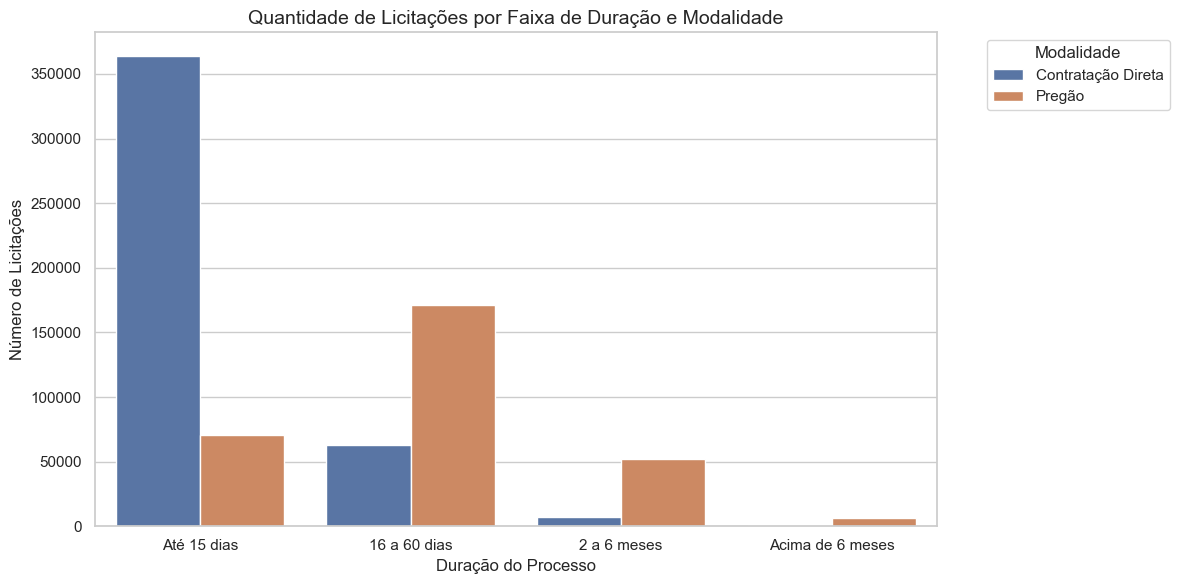

In [44]:
# 1. Ajuste nos intervalos (bins) e legendas (labels)
# Agora o último intervalo começa em 181 e vai até o infinito
bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = [
    'Até 15 dias',
    '16 a 60 dias',
    '2 a 6 meses',
    'Acima de 6 meses'
]

# 2. Criar a nova coluna de faixas de duração
base_unificada['faixa_duracao'] = pd.cut(
    base_unificada['duracao_dias'],
    bins=bins,
    labels=labels
)

# 3. Agrupar os dados
df_plot = base_unificada.groupby(['faixa_duracao', 'modalidade_grupo'], observed=True).size().reset_index(name='quantidade')

# 4. Configuração visual do gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras agrupadas
plot = sns.barplot(
    data=df_plot,
    x='faixa_duracao',
    y='quantidade',
    hue='modalidade_grupo'
)

# Ajustes de títulos e eixos
plt.title('Quantidade de Licitações por Faixa de Duração e Modalidade', fontsize=14)
plt.xlabel('Duração do Processo', fontsize=12)
plt.ylabel('Número de Licitações', fontsize=12)
plt.legend(title='Modalidade', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

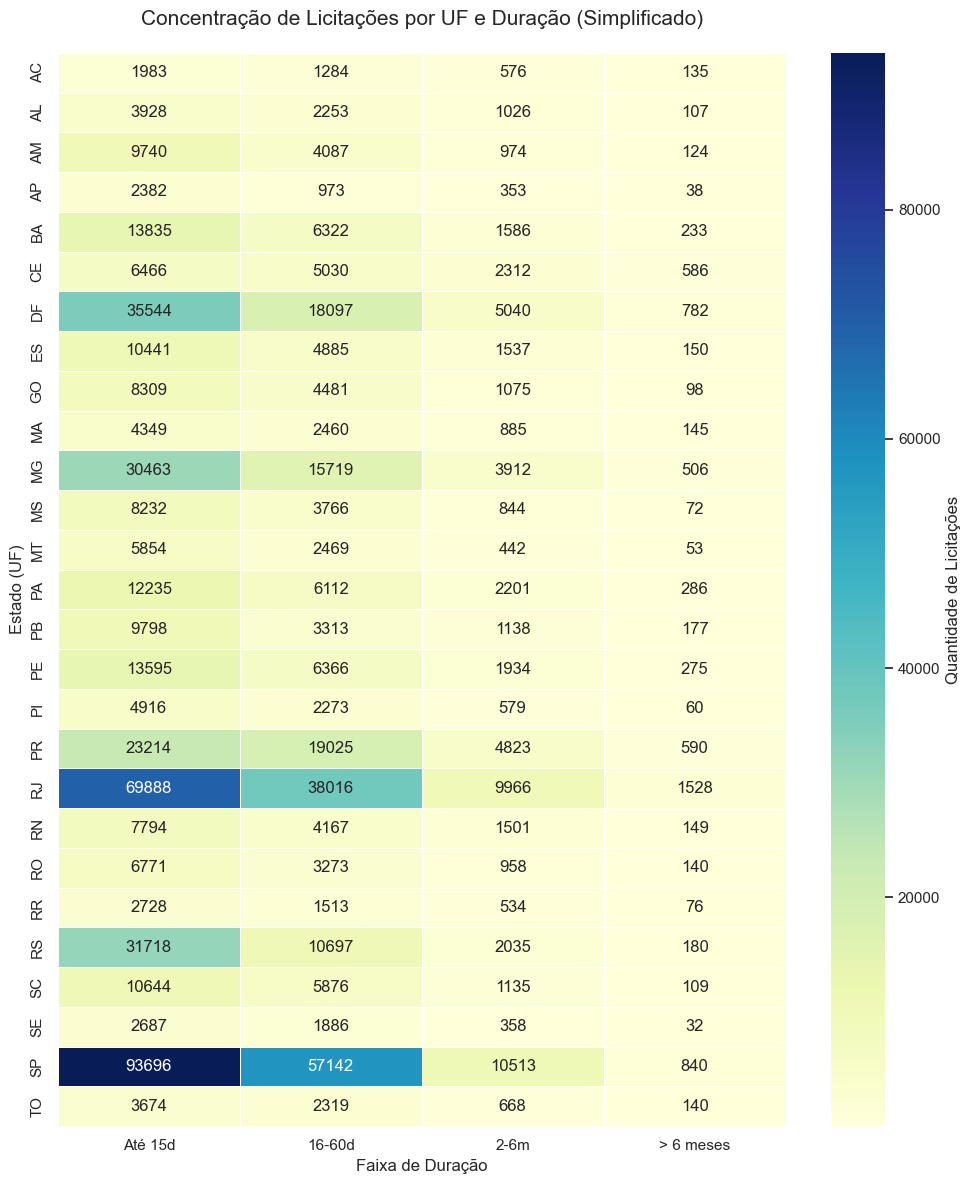

In [45]:

# 1. Preparação dos dados com as novas faixas (Até 6 meses e Acima)
bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = ['Até 15d', '16-60d', '2-6m', '> 6 meses']
base_unificada['faixa_duracao'] = pd.cut(base_unificada['duracao_dias'], bins=bins, labels=labels)

# 2. Criar tabela dinâmica (Pivot Table) para o Heatmap
# Usamos 'observed=True' para garantir que apenas as faixas definidas apareçam
df_heatmap = base_unificada.pivot_table(
    index='uf',
    columns='faixa_duracao',
    values='id_licitacao',
    aggfunc='count',
    fill_value=0,
    observed=True
)

# 3. Plotar o Heatmap
plt.figure(figsize=(10, 12)) # Ajustado para acomodar melhor os 27 estados
sns.set_theme(style="white")

# Dica: 'fmt="d"' escreve os números inteiros. Se os números forem muito grandes,
# o gráfico pode poluir. Se preferir, use fmt=".2s" para notação científica amigável.
sns.heatmap(
    df_heatmap,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Quantidade de Licitações'}
)

plt.title('Concentração de Licitações por UF e Duração (Simplificado)', fontsize=15, pad=20)
plt.xlabel('Faixa de Duração', fontsize=12)
plt.ylabel('Estado (UF)', fontsize=12)

plt.tight_layout()
plt.show()
# plt.savefig('heatmap_licitacoes_uf_ajustado.png') # Opcional para salvar

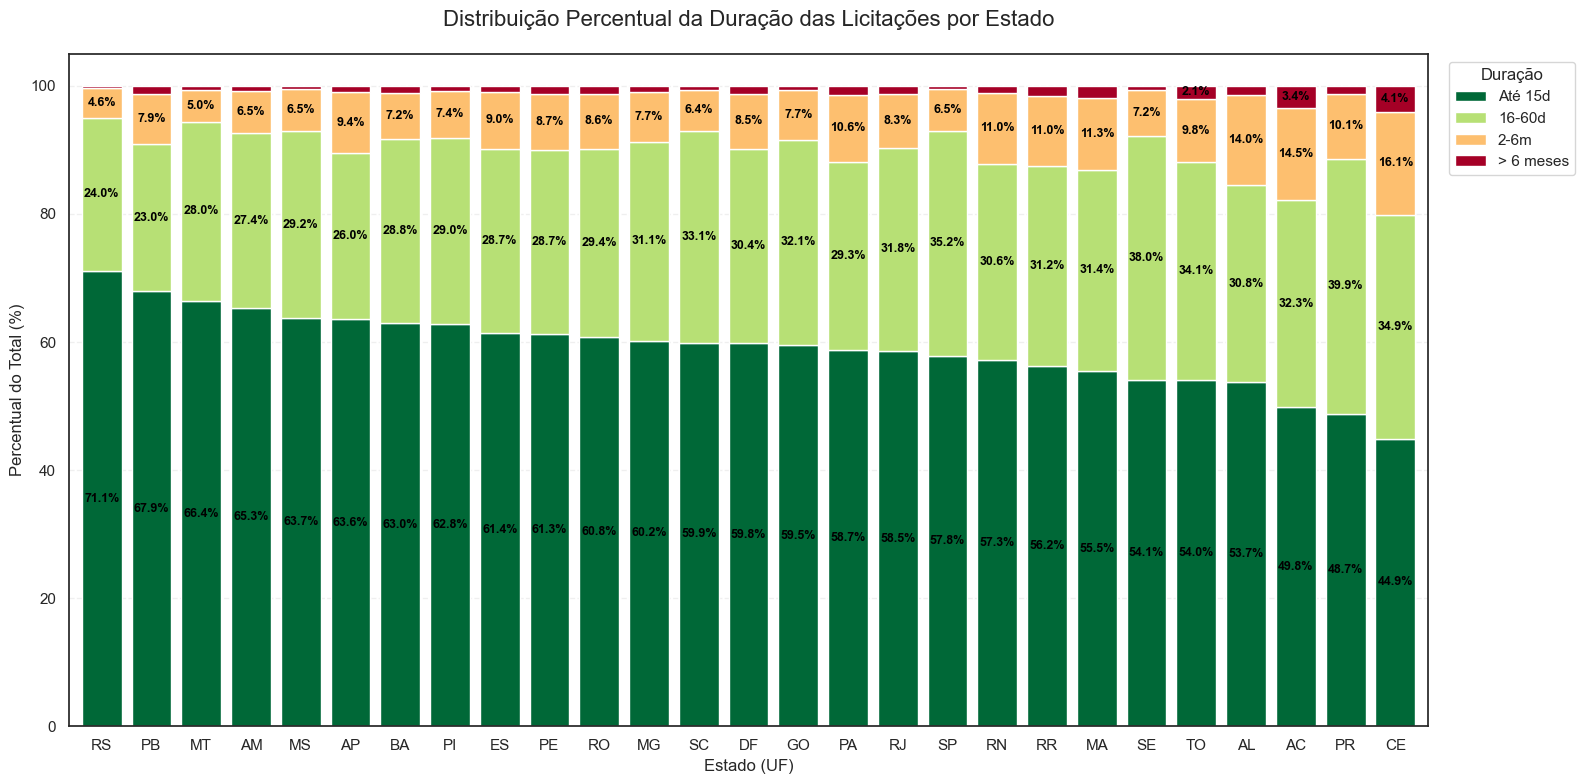

In [46]:
# 1. Preparação das faixas (Bins e Labels conforme solicitado)
bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = ['Até 15d', '16-60d', '2-6m', '> 6 meses']
base_unificada['faixa_duracao'] = pd.cut(base_unificada['duracao_dias'], bins=bins, labels=labels)

# 2. Gerar Tabela de Proporções (Crosstab)
df_prop = pd.crosstab(base_unificada['uf'], base_unificada['faixa_duracao'], normalize='index') * 100

# 3. Ordenar os estados pelo maior percentual de processos rápidos (Até 15d)
df_prop = df_prop.sort_values('Até 15d', ascending=False)

# 4. Plotar o gráfico de barras empilhadas
# Usando 'RdYlGn_r' (Vermelho para longo prazo, Verde para curto prazo)
ax = df_prop.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='RdYlGn_r', width=0.8)

# 5. Adicionar os rótulos de porcentagem dentro das barras (Opcional, mas recomendado)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 2: # Só mostra o texto se a fatia for maior que 2% para não embolar
        x, y = p.get_xy()
        ax.text(x + width/2,
                y + height/2,
                f'{height:.1f}%',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=9,
                color='black',
                fontweight='bold')

# 6. Ajustes finais de layout
plt.title('Distribuição Percentual da Duração das Licitações por Estado', fontsize=16, pad=20)
plt.ylabel('Percentual do Total (%)', fontsize=12)
plt.xlabel('Estado (UF)', fontsize=12)
plt.xticks(rotation=0) # Estados na horizontal
plt.legend(title='Duração', bbox_to_anchor=(1.01, 1), loc='upper left')

# Linha de grade horizontal suave
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
print("\n--- INFORMAÇÕES GERAIS ---")
base_robustez.info()


--- INFORMAÇÕES GERAIS ---
<class 'pandas.DataFrame'>
Index: 314339 entries, 1 to 778225
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_licitacao      314339 non-null  object        
 1   modalidade        314339 non-null  string        
 2   uf                314339 non-null  string        
 3   data_abertura     314339 non-null  datetime64[us]
 4   data_resultado    314339 non-null  datetime64[us]
 5   valor_licitacao   314339 non-null  Float64       
 6   arquivo_origem    314339 non-null  str           
 7   duracao_dias      314339 non-null  int64         
 8   fonte             314339 non-null  str           
 9   ano_licitacao     314339 non-null  int32         
 10  periodo_legal     314339 non-null  str           
 11  modalidade_grupo  314339 non-null  str           
dtypes: Float64(1), datetime64[us](2), int32(1), int64(1), object(1), str(4), string(2)
memory usage: 30.3+

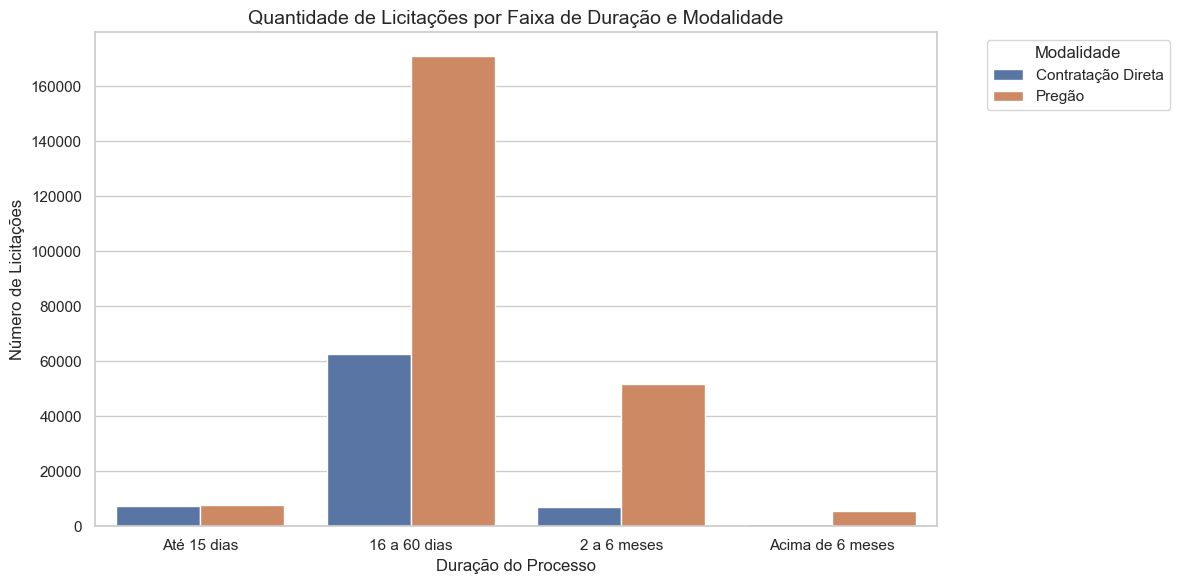

In [48]:
# 1. Ajuste nos intervalos (bins) e legendas (labels)
# Agora o último intervalo começa em 181 e vai até o infinito
bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = [
    'Até 15 dias',
    '16 a 60 dias',
    '2 a 6 meses',
    'Acima de 6 meses'
]

# 2. Criar a nova coluna de faixas de duração
base_robustez['faixa_duracao'] = pd.cut(
    base_robustez['duracao_dias'],
    bins=bins,
    labels=labels
)

# 3. Agrupar os dados
df_plot = base_robustez.groupby(['faixa_duracao', 'modalidade_grupo'], observed=True).size().reset_index(name='quantidade')

# 4. Configuração visual do gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras agrupadas
plot = sns.barplot(
    data=df_plot,
    x='faixa_duracao',
    y='quantidade',
    hue='modalidade_grupo'
)

# Ajustes de títulos e eixos
plt.title('Quantidade de Licitações por Faixa de Duração e Modalidade', fontsize=14)
plt.xlabel('Duração do Processo', fontsize=12)
plt.ylabel('Número de Licitações', fontsize=12)
plt.legend(title='Modalidade', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

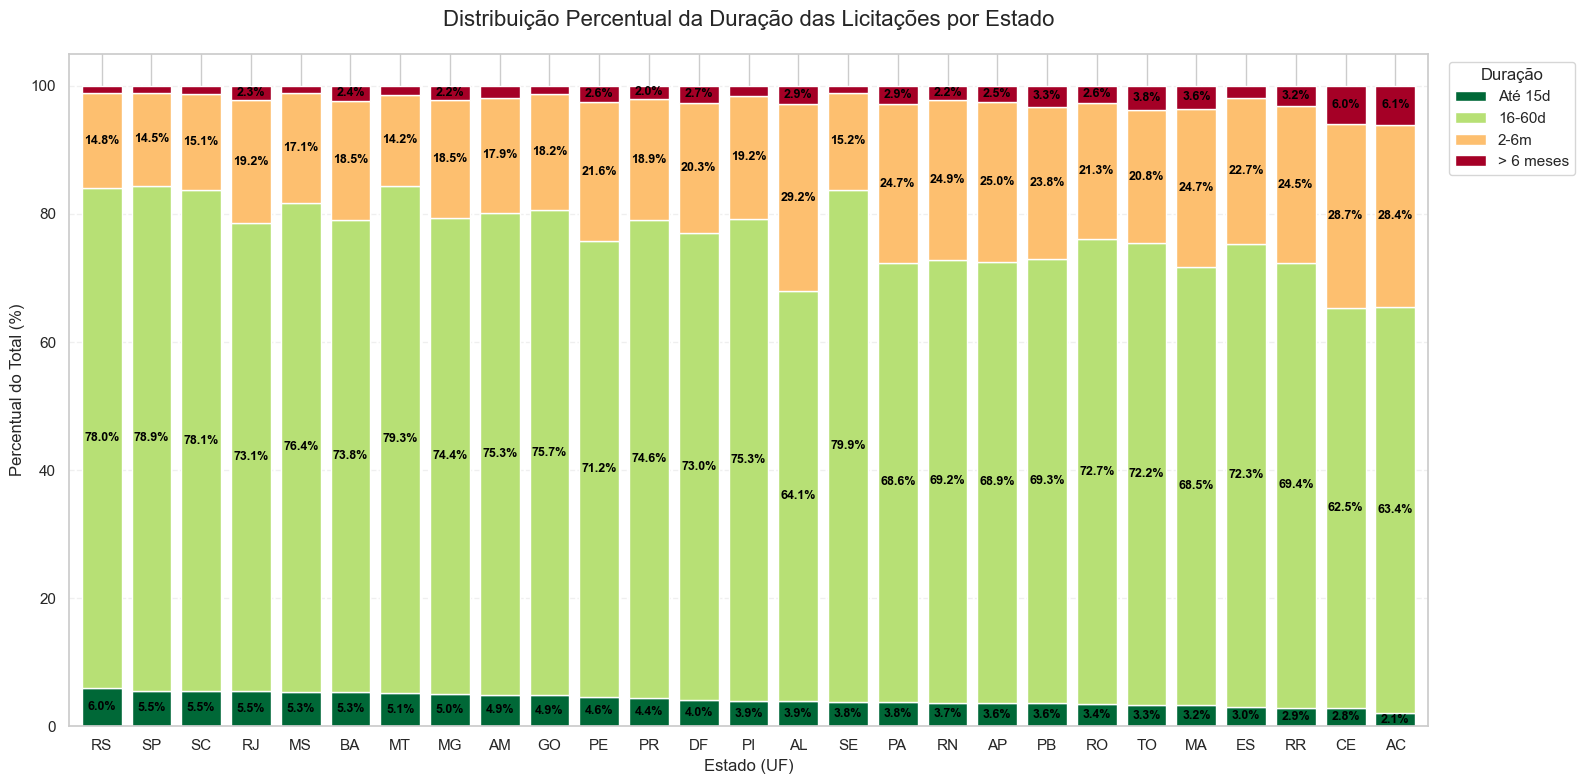

In [49]:
# 1. Preparação das faixas (Bins e Labels conforme solicitado)
bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = ['Até 15d', '16-60d', '2-6m', '> 6 meses']
base_robustez['faixa_duracao'] = pd.cut(base_robustez['duracao_dias'], bins=bins, labels=labels)

# 2. Gerar Tabela de Proporções (Crosstab)
df_prop = pd.crosstab(base_robustez['uf'], base_robustez['faixa_duracao'], normalize='index') * 100

# 3. Ordenar os estados pelo maior percentual de processos rápidos (Até 15d)
df_prop = df_prop.sort_values('Até 15d', ascending=False)

# 4. Plotar o gráfico de barras empilhadas
# Usando 'RdYlGn_r' (Vermelho para longo prazo, Verde para curto prazo)
ax = df_prop.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='RdYlGn_r', width=0.8)

# 5. Adicionar os rótulos de porcentagem dentro das barras (Opcional, mas recomendado)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 2: # Só mostra o texto se a fatia for maior que 2% para não embolar
        x, y = p.get_xy()
        ax.text(x + width/2,
                y + height/2,
                f'{height:.1f}%',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=9,
                color='black',
                fontweight='bold')

# 6. Ajustes finais de layout
plt.title('Distribuição Percentual da Duração das Licitações por Estado', fontsize=16, pad=20)
plt.ylabel('Percentual do Total (%)', fontsize=12)
plt.xlabel('Estado (UF)', fontsize=12)
plt.xticks(rotation=0) # Estados na horizontal
plt.legend(title='Duração', bbox_to_anchor=(1.01, 1), loc='upper left')

# Linha de grade horizontal suave
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

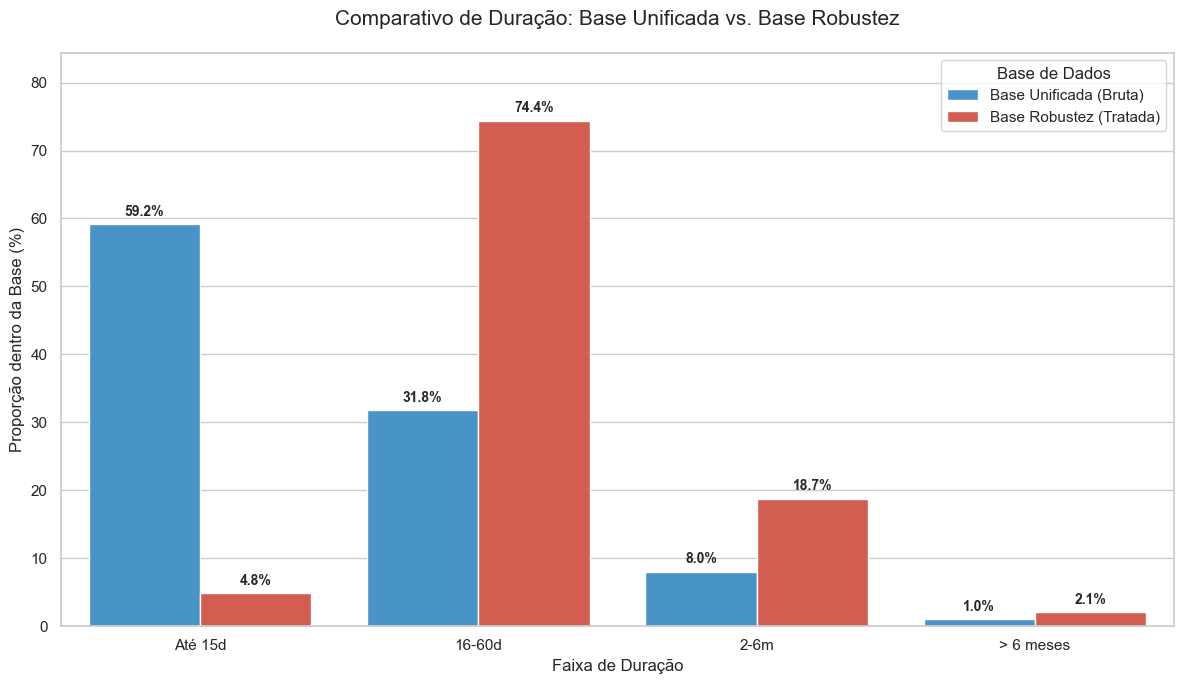

In [50]:
# 1. Configurações de faixas (conforme ajustado anteriormente)
bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = ['Até 15d', '16-60d', '2-6m', '> 6 meses']

# 2. Função para processar a distribuição percentual de cada base
def calcular_distribuicao(df, nome_base):
    # Criamos a coluna de faixa se ela ainda não existir
    df['faixa_duracao'] = pd.cut(df['duracao_dias'], bins=bins, labels=labels)

    # Calculamos a porcentagem de cada categoria
    dist = df['faixa_duracao'].value_counts(normalize=True).sort_index() * 100
    dist_df = dist.reset_index()
    dist_df.columns = ['Faixa', 'Porcentagem']
    dist_df['Origem'] = nome_base
    return dist_df

# 3. Gerar os dados para as duas bases
dist_unificada = calcular_distribuicao(base_unificada, 'Base Unificada (Bruta)')
dist_robustez = calcular_distribuicao(base_robustez, 'Base Robustez (Tratada)')

# 4. Unificar os resultados para o gráfico
df_comparativo = pd.concat([dist_unificada, dist_robustez])

# 5. Plotar o gráfico comparativo
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_comparativo,
    x='Faixa',
    y='Porcentagem',
    hue='Origem',
    palette=['#3498db', '#e74c3c'] # Azul para bruta, Vermelho para tratada
)

# Adicionar os valores em cima das barras para facilitar a leitura
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

# Ajustes finais
plt.title('Comparativo de Duração: Base Unificada vs. Base Robustez', fontsize=15, pad=20)
plt.ylabel('Proporção dentro da Base (%)', fontsize=12)
plt.xlabel('Faixa de Duração', fontsize=12)
plt.ylim(0, df_comparativo['Porcentagem'].max() + 10) # Dá espaço para o texto em cima
plt.legend(title='Base de Dados')

plt.tight_layout()
plt.show()

In [51]:
def gerar_resumo_estatistico(df_unificada, df_robustez):
    # Definindo os bins novamente para garantir consistência
    bins = [-float('inf'), 15, 60, 180, float('inf')]
    labels = ['Até 15d', '16-60d', '2-6m', '> 6 meses']

    # Processando Base Unificada
    df_unificada['faixa_duracao'] = pd.cut(df_unificada['duracao_dias'], bins=bins, labels=labels)
    resumo_uni = df_unificada['faixa_duracao'].value_counts().sort_index().to_frame(name='Qtd_Unificada')
    resumo_uni['%_Unificada'] = (df_unificada['faixa_duracao'].value_counts(normalize=True).sort_index() * 100).round(2)

    # Processando Base Robustez
    df_robustez['faixa_duracao'] = pd.cut(df_robustez['duracao_dias'], bins=bins, labels=labels)
    resumo_rob = df_robustez['faixa_duracao'].value_counts().sort_index().to_frame(name='Qtd_Robustez')
    resumo_rob['%_Robustez'] = (df_robustez['faixa_duracao'].value_counts(normalize=True).sort_index() * 100).round(2)

    # Unindo os dois resumos
    comparativo = pd.concat([resumo_uni, resumo_rob], axis=1)

    # Print do bloco de texto para copiar
    print("=== DADOS PARA ANÁLISE DE ROBUSTEZ ===")
    print(f"Total Unificada: {len(df_unificada)} linhas")
    print(f"Total Robustez: {len(df_robustez)} linhas")
    print("\nTABELA COMPARATIVA:")
    print(comparativo.to_string())
    print("\nESTATÍSTICAS DA COLUNA DURACAO_DIAS:")
    print("\nUnificada:")
    print(df_unificada['duracao_dias'].describe().round(2))
    print("\nRobustez:")
    print(df_robustez['duracao_dias'].describe().round(2))

# Executar a função
gerar_resumo_estatistico(base_unificada, base_robustez)

=== DADOS PARA ANÁLISE DE ROBUSTEZ ===
Total Unificada: 735204 linhas
Total Robustez: 314339 linhas

TABELA COMPARATIVA:
               Qtd_Unificada  %_Unificada  Qtd_Robustez  %_Robustez
faixa_duracao                                                      
Até 15d               434884        59.15         15170        4.83
16-60d                233804        31.80        233804       74.38
2-6m                   58905         8.01         58905       18.74
> 6 meses               7611         1.04          6460        2.06

ESTATÍSTICAS DA COLUNA DURACAO_DIAS:

Unificada:
count    735204.00
mean         22.90
std          45.18
min           0.00
25%           0.00
50%          11.00
75%          28.00
max        3508.00
Name: duracao_dias, dtype: float64

Robustez:
count    314339.00
mean         46.18
std          41.40
min          15.00
25%          21.00
50%          32.00
75%          54.00
max         365.00
Name: duracao_dias, dtype: float64


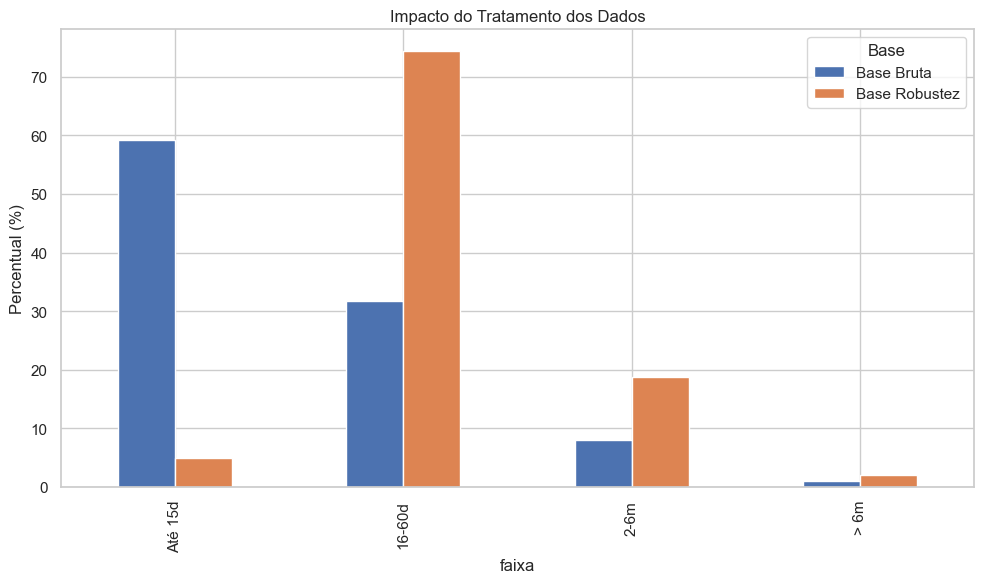

In [52]:
# ===== FIGURA 1 =====

bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = ['Até 15d', '16-60d', '2-6m', '> 6m']

base_unificada['faixa'] = pd.cut(base_unificada['duracao_dias'], bins=bins, labels=labels)
base_robustez['faixa'] = pd.cut(base_robustez['duracao_dias'], bins=bins, labels=labels)

dist_uni = base_unificada['faixa'].value_counts(normalize=True) * 100
dist_rob = base_robustez['faixa'].value_counts(normalize=True) * 100

df_plot = pd.DataFrame({
    'Base Bruta': dist_uni,
    'Base Robustez': dist_rob
}).fillna(0)

df_plot.plot(kind='bar', figsize=(10,6))
plt.ylabel('Percentual (%)')
plt.title('Impacto do Tratamento dos Dados')
plt.legend(title='Base')
plt.tight_layout()
plt.show()

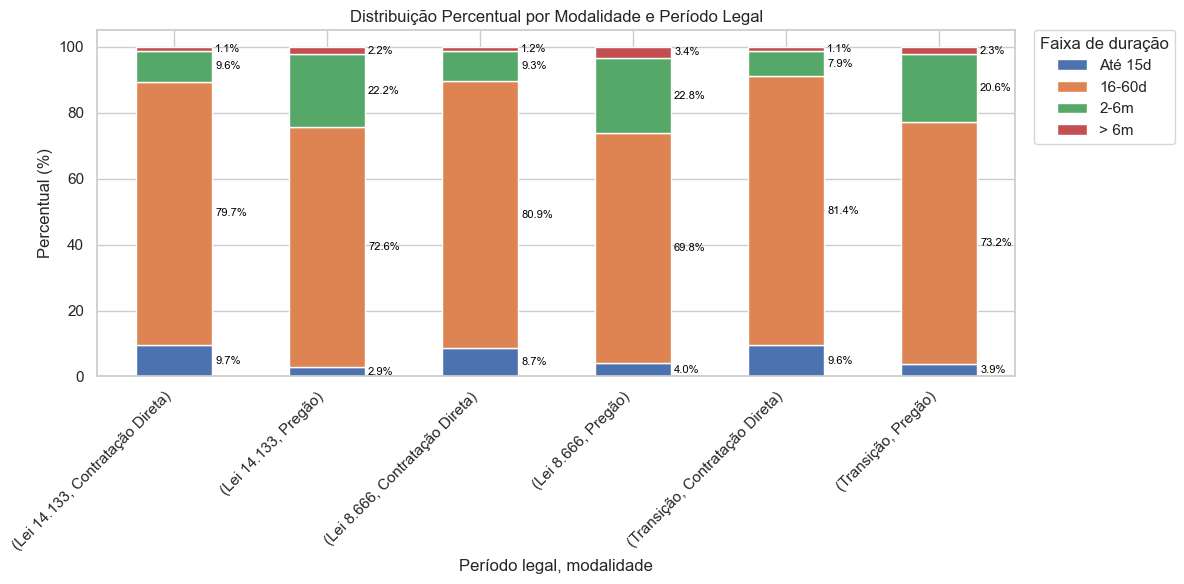

In [53]:
# ===== FIGURA 2 =====
# Distribuição percentual por modalidade e período legal (mantendo "Até 15d")
# + rótulos fora (à direita) de cada segmento

# 1) Faixas
bins = [-float('inf'), 15, 60, 180, float('inf')]
labels = ['Até 15d', '16-60d', '2-6m', '> 6m']

base_robustez = base_robustez.copy()
base_robustez['faixa'] = pd.cut(base_robustez['duracao_dias'], bins=bins, labels=labels)

# 2) Crosstab normalizado por linha (cada barra soma 100%)
df_ct = pd.crosstab(
    [base_robustez['periodo_legal'], base_robustez['modalidade_grupo']],
    base_robustez['faixa'],
    normalize='index'
) * 100

# garante ordem das colunas
df_ct = df_ct.reindex(columns=labels).fillna(0)

# 3) Plot
ax = df_ct.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.ylabel('Percentual (%)')
plt.xlabel('Período legal, modalidade')
plt.title('Distribuição Percentual por Modalidade e Período Legal')

# 4) Legenda fora do gráfico
plt.legend(
    title='Faixa de duração',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

# 5) Rótulos fora (à direita) de cada segmento
# Estratégia: para cada patch (retângulo), escrever no ponto (x_right + offset, y_center)
# e só escrever se for >= 0.5% (ajuste o limiar se quiser mostrar tudo).
limiar = 0.5

for p in ax.patches:
    w = p.get_width()
    h = p.get_height()
    if h <= 0:
        continue
    val = h  # já está em %
    if val < limiar:
        continue

    x = p.get_x() + w
    y = p.get_y() + h / 2

    ax.text(
        x + 0.02, y, f"{val:.1f}%",
        va='center', ha='left', fontsize=8, color='black'
    )

# 6) Melhorar leitura dos rótulos do eixo x
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

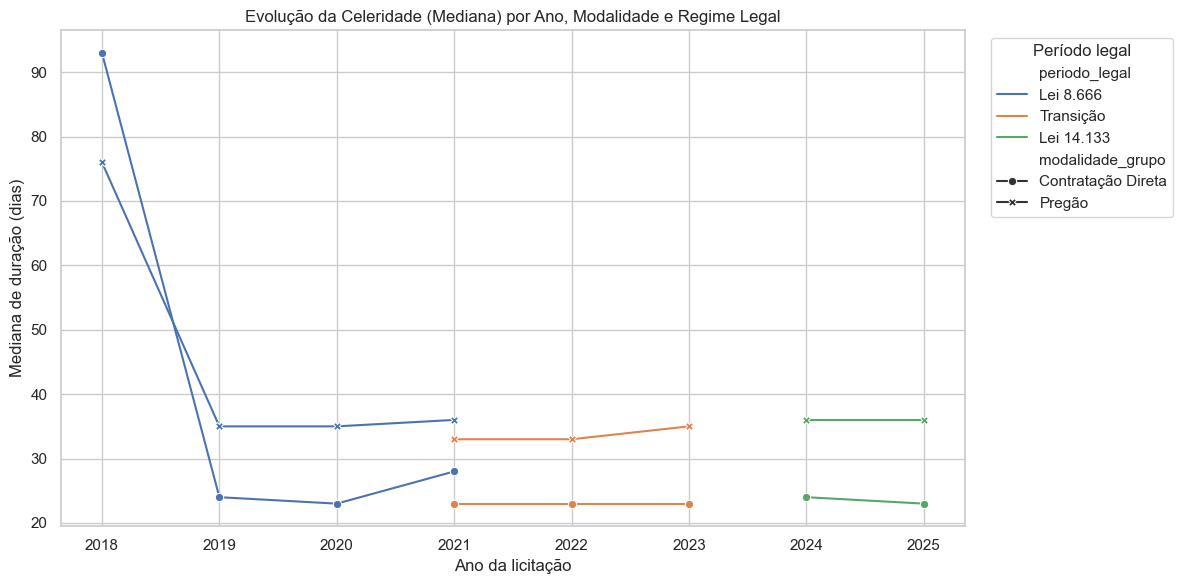

In [54]:
# ===== FIGURA 3 =====
# Evolução anual da mediana de duração (base robustez), por modalidade e período legal

df_evolucao = (
    base_robustez
    .groupby(['ano_licitacao', 'modalidade_grupo', 'periodo_legal'])['duracao_dias']
    .median()
    .reset_index(name='mediana_dias')
)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_evolucao,
    x='ano_licitacao',
    y='mediana_dias',
    hue='periodo_legal',
    style='modalidade_grupo',
    markers=True,
    dashes=False
)

plt.title('Evolução da Celeridade (Mediana) por Ano, Modalidade e Regime Legal')
plt.xlabel('Ano da licitação')
plt.ylabel('Mediana de duração (dias)')
plt.legend(title='Período legal', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

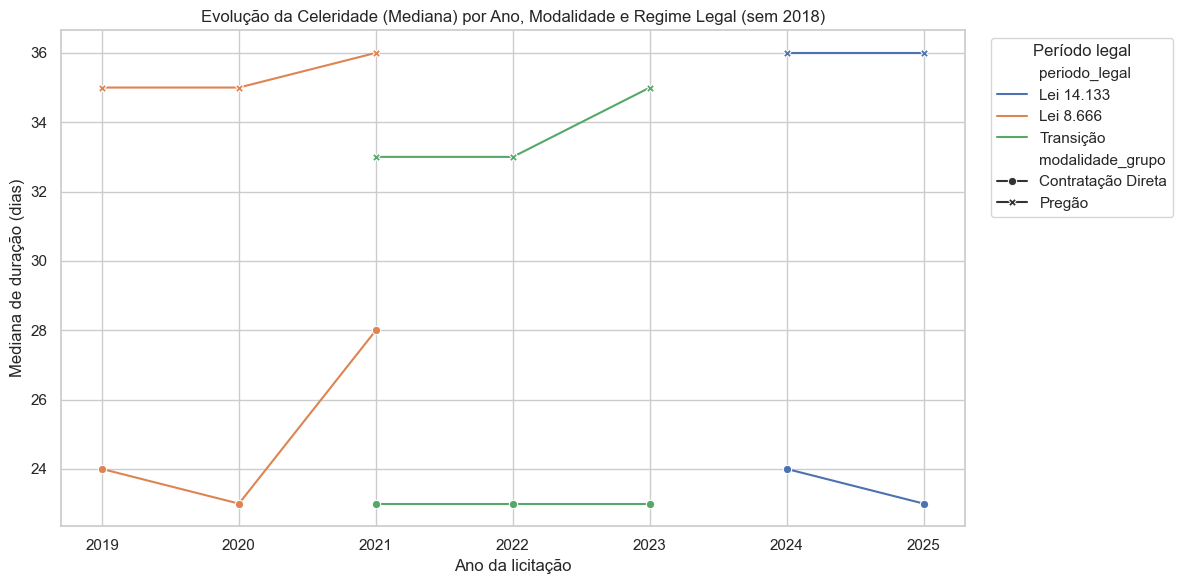

In [55]:
# ==== FIGURA 3 (sem 2018) ====
df_evolucao = (
    base_robustez
    .groupby(['ano_licitacao', 'modalidade_grupo', 'periodo_legal'])['duracao_dias']
    .median()
    .reset_index(name='mediana_dias')
)

# Remover 2018
df_evolucao = df_evolucao[df_evolucao['ano_licitacao'] != 2018].copy()
# (opcional) garantir ordem
df_evolucao = df_evolucao.sort_values(['modalidade_grupo', 'periodo_legal', 'ano_licitacao'])

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_evolucao,
    x='ano_licitacao',
    y='mediana_dias',
    hue='periodo_legal',
    style='modalidade_grupo',
    markers=True,
    dashes=False
)

plt.title('Evolução da Celeridade (Mediana) por Ano, Modalidade e Regime Legal (sem 2018)')
plt.xlabel('Ano da licitação')
plt.ylabel('Mediana de duração (dias)')
plt.legend(title='Período legal', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

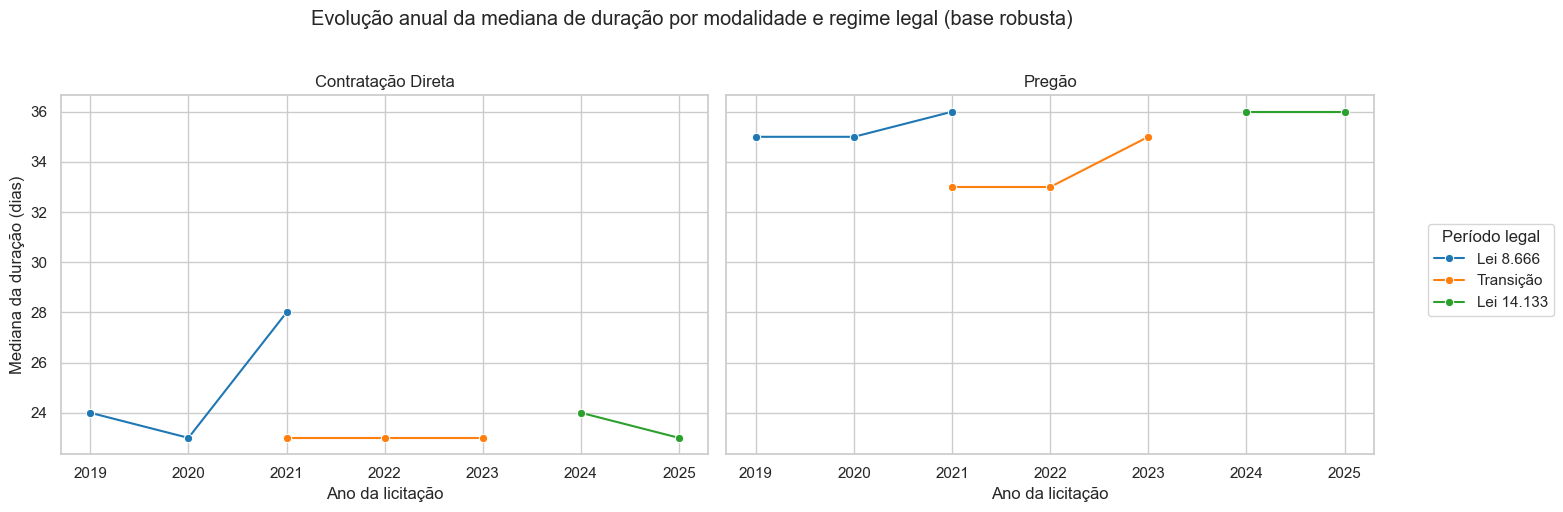

In [56]:
# ==============================
# FIGURA (versão limpa): 2 painéis lado a lado
# Painel A: Contratação Direta
# Painel B: Pregão
# Cores: período legal
# ==============================

# 1) Recalcular df_evolucao (se você já tiver, pode pular esta parte)
df_evolucao = (
    base_robustez
    .groupby(['ano_licitacao', 'modalidade_grupo', 'periodo_legal'])['duracao_dias']
    .median()
    .reset_index(name='mediana_dias')
)

# 2) Remover 2018
df_evolucao = df_evolucao[df_evolucao['ano_licitacao'] != 2018].copy()

# 3) Garantir ordem lógica dos períodos na legenda
ordem_periodo = ['Lei 8.666', 'Transição', 'Lei 14.133']
df_evolucao['periodo_legal'] = pd.Categorical(df_evolucao['periodo_legal'],
                                             categories=ordem_periodo, ordered=True)

# 4) Paleta consistente e "publicável"
palette = {
    'Lei 8.666': '#1f77b4',   # azul
    'Transição': '#ff7f0e',   # laranja
    'Lei 14.133': '#2ca02c'   # verde
}

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Painel A - Contratação Direta
df_cd = df_evolucao[df_evolucao['modalidade_grupo'] == 'Contratação Direta']
sns.lineplot(
    data=df_cd,
    x='ano_licitacao',
    y='mediana_dias',
    hue='periodo_legal',
    palette=palette,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Contratação Direta')
axes[0].set_xlabel('Ano da licitação')
axes[0].set_ylabel('Mediana da duração (dias)')

# Painel B - Pregão
df_pr = df_evolucao[df_evolucao['modalidade_grupo'] == 'Pregão']
sns.lineplot(
    data=df_pr,
    x='ano_licitacao',
    y='mediana_dias',
    hue='periodo_legal',
    palette=palette,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Pregão')
axes[1].set_xlabel('Ano da licitação')
axes[1].set_ylabel('')  # já compartilha o Y

# Remover legendas individuais
axes[0].legend_.remove()
axes[1].legend_.remove()

# Legenda única fora (direita)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Período legal',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

fig.suptitle('Evolução anual da mediana de duração por modalidade e regime legal (base robusta)', y=1.02)
plt.tight_layout()
plt.show()

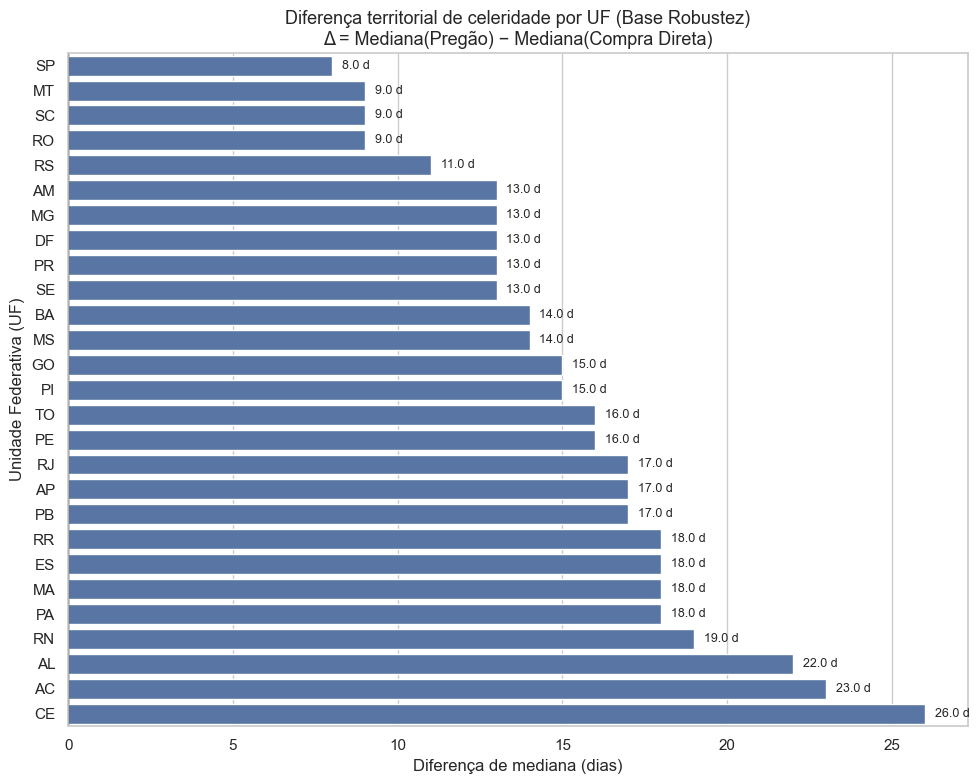

In [57]:
# ===== FIGURA 4 =====
# Diferença territorial (UF): mediana(Pregão) - mediana(Compra Direta) na Base Robustez

# 1) Calcular mediana por UF e modalidade (Base Robustez)
uf_mediana = (
    base_robustez
    .groupby(["uf", "modalidade_grupo"])["duracao_dias"]
    .median()
    .reset_index()
)

# 2) Pivotar para ter uma coluna por modalidade
uf_pivot = (
    uf_mediana
    .pivot(index="uf", columns="modalidade_grupo", values="duracao_dias")
    .reset_index()
)

# Garantir que as colunas existam (segurança)
cols_needed = ["Contratação Direta", "Pregão"]
missing = [c for c in cols_needed if c not in uf_pivot.columns]
if missing:
    raise ValueError(f"Faltam colunas na pivot: {missing}. Verifique 'modalidade_grupo'.")

# 3) Diferença: pregão - compra direta
uf_pivot["dif_pregao_menos_cd"] = uf_pivot["Pregão"] - uf_pivot["Contratação Direta"]

# 4) Ordenar para visualização
uf_pivot = uf_pivot.sort_values("dif_pregao_menos_cd", ascending=True)

# 5) Plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=uf_pivot,
    x="dif_pregao_menos_cd",
    y="uf",
    color="#4C72B0"
)

# Linha de referência no zero
ax.axvline(0, color="black", linewidth=1)

# Rótulos (valores) ao final de cada barra
for i, v in enumerate(uf_pivot["dif_pregao_menos_cd"].values):
    ax.text(
        v + (0.3 if v >= 0 else -0.3),
        i,
        f"{v:.1f} d",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9
    )

plt.title("Diferença territorial de celeridade por UF (Base Robustez)\nΔ = Mediana(Pregão) − Mediana(Compra Direta)", fontsize=13)
plt.xlabel("Diferença de mediana (dias)")
plt.ylabel("Unidade Federativa (UF)")

plt.tight_layout()
plt.show()

In [58]:
# 1) O dataframe precisa ter: uf (sigla) e dif_pregao_menos_cd
# Ex.: uf_pivot tem colunas ["uf", "Contratação Direta", "Pregão", "dif_pregao_menos_cd"]
df_map = uf_pivot[["uf", "dif_pregao_menos_cd"]].copy()
df_map["dif_pregao_menos_cd"] = pd.to_numeric(df_map["dif_pregao_menos_cd"], errors="coerce")

# 2) Baixar GeoJSON de UFs (sigla em properties.sigla)
geo_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
geojson_uf = requests.get(geo_url).json()

# 3) Choropleth
fig = px.choropleth(
    df_map,
    geojson=geojson_uf,
    locations="uf",
    featureidkey="properties.sigla",   # <- campo do GeoJSON que casa com "SP", "RJ" etc.
    color="dif_pregao_menos_cd",
    color_continuous_scale="RdYlGn_r",
    range_color=(8, 26),
    labels={"dif_pregao_menos_cd": "Δ mediana (dias)"},
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(
    title="Diferença Territorial de Celeridade por Unidade Federativa<br><sup>Δ = Mediana(Pregão) − Mediana(Compra Direta) | Base Robustez</sup>",
    margin=dict(l=0, r=0, t=60, b=0),
    coloraxis_colorbar=dict(title="Δ (dias)")
)

fig.show()

NameError: name 'requests' is not defined

In [59]:
def resumo_iqr(df, col_valor='duracao_dias', grupo1='periodo_legal', grupo2='modalidade_grupo'):
    # quantis
    q = (
        df
        .groupby([grupo1, grupo2])[col_valor]
        .quantile([0.25, 0.50, 0.75])
        .unstack(level=-1)  # colunas viram 0.25, 0.5, 0.75
        .rename(columns={0.25: 'Q1', 0.50: 'Mediana', 0.75: 'Q3'})
        .reset_index()
    )

    # contagem
    n = (
        df
        .groupby([grupo1, grupo2])[col_valor]
        .size()
        .reset_index(name='n')
    )

    # merge
    out = q.merge(n, on=[grupo1, grupo2], how='left')

    # IQR
    out['IQR'] = out['Q3'] - out['Q1']

    # arredondar (duração é em dias, então faz sentido 0 casas)
    out[['Q1', 'Mediana', 'Q3', 'IQR']] = out[['Q1', 'Mediana', 'Q3', 'IQR']].round(0)

    # ordenar
    out = out.sort_values([grupo1, grupo2]).reset_index(drop=True)
    return out

tabela_iqr = resumo_iqr(base_robustez)

print("\n=== TABELA IQR (por período legal e modalidade) ===")
print(tabela_iqr.to_string(index=False))


=== TABELA IQR (por período legal e modalidade) ===
periodo_legal   modalidade_grupo   Q1  Mediana   Q3      n  IQR
   Lei 14.133 Contratação Direta 18.0     23.0 36.0  43804 18.0
   Lei 14.133             Pregão 24.0     36.0 60.0 156074 36.0
    Lei 8.666 Contratação Direta 19.0     24.0 37.0   8830 18.0
    Lei 8.666             Pregão 23.0     36.0 62.0  29580 39.0
    Transição Contratação Direta 18.0     23.0 35.0  25476 17.0
    Transição             Pregão 22.0     34.0 57.0  50575 35.0


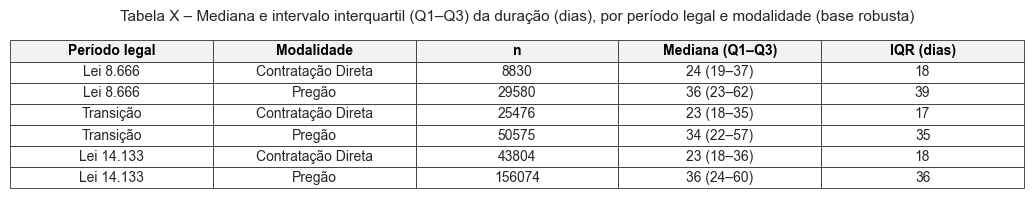

,Período legal,Modalidade,n,Mediana (Q1–Q3),IQR (dias)
0,Lei 8.666,Contratação Direta,8830,24 (19–37),18
1,Lei 8.666,Pregão,29580,36 (23–62),39
2,Transição,Contratação Direta,25476,23 (18–35),17
3,Transição,Pregão,50575,34 (22–57),35
4,Lei 14.133,Contratação Direta,43804,23 (18–36),18
5,Lei 14.133,Pregão,156074,36 (24–60),36


In [60]:
# --- 1) Partir da tabela longa (a "primeira tabela") ---
df = tabela_iqr.copy()

# (opcional) ordenar período legal numa ordem lógica
ordem_periodo = ["Lei 8.666", "Transição", "Lei 14.133"]
df["periodo_legal"] = pd.Categorical(df["periodo_legal"], categories=ordem_periodo, ordered=True)
df = df.sort_values(["periodo_legal", "modalidade_grupo"]).reset_index(drop=True)

# --- 2) Formatar números (dias) e criar coluna Mediana (Q1–Q3) ---
for col in ["Q1", "Mediana", "Q3", "IQR"]:
    df[col] = df[col].round(0).astype(int)

df["n"] = df["n"].astype(int)

df["Mediana (Q1–Q3)"] = df["Mediana"].astype(str) + " (" + df["Q1"].astype(str) + "–" + df["Q3"].astype(str) + ")"

# --- 3) Selecionar e renomear colunas (mais “artigo”) ---
tabela_artigo = df[[
    "periodo_legal",
    "modalidade_grupo",
    "n",
    "Mediana (Q1–Q3)",
    "IQR"
]].rename(columns={
    "periodo_legal": "Período legal",
    "modalidade_grupo": "Modalidade",
    "n": "n",
    "IQR": "IQR (dias)"
})

# --- 4) Renderizar como tabela em figura ---
fig, ax = plt.subplots(figsize=(10.5, 2.2))  # ajuste se ficar apertado
ax.axis("off")

tbl = ax.table(
    cellText=tabela_artigo.values,
    colLabels=tabela_artigo.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# Estilo “publicável”
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.35)

# Cabeçalho em negrito + fundo claro
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold", color="black")
        cell.set_facecolor("#F2F2F2")
    cell.set_edgecolor("#333333")
    cell.set_linewidth(0.6)

plt.title("Tabela X – Mediana e intervalo interquartil (Q1–Q3) da duração (dias), por período legal e modalidade (base robusta)",
          fontsize=11, pad=10)

plt.tight_layout()
plt.savefig("tabela_iqr_artigo.png", dpi=300, bbox_inches="tight")
plt.show()

tabela_artigo

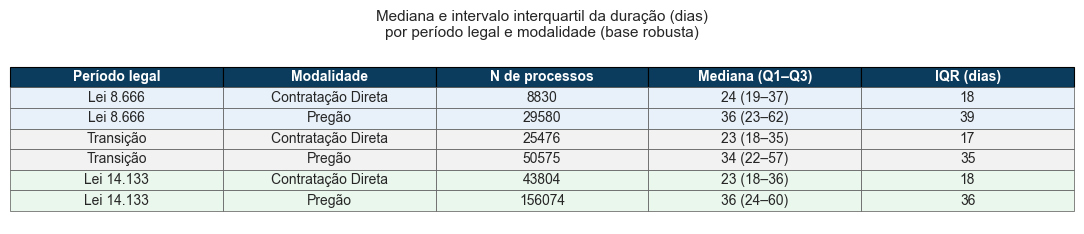

In [61]:
df = tabela_iqr.copy()

# Ordem lógica dos períodos
ordem_periodo = ["Lei 8.666", "Transição", "Lei 14.133"]
df["periodo_legal"] = pd.Categorical(df["periodo_legal"], categories=ordem_periodo, ordered=True)
df = df.sort_values(["periodo_legal", "modalidade_grupo"]).reset_index(drop=True)

# Formatação
for col in ["Q1", "Mediana", "Q3", "IQR"]:
    df[col] = df[col].round(0).astype(int)

df["n"] = df["n"].astype(int)

df["Mediana (Q1–Q3)"] = (
    df["Mediana"].astype(str) + " (" +
    df["Q1"].astype(str) + "–" +
    df["Q3"].astype(str) + ")"
)

tabela_final = df[[
    "periodo_legal",
    "modalidade_grupo",
    "n",
    "Mediana (Q1–Q3)",
    "IQR"
]].rename(columns={
    "periodo_legal": "Período legal",
    "modalidade_grupo": "Modalidade",
    "n": "N de processos",
    "IQR": "IQR (dias)"
})

# === Renderização ===
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis("off")

tbl = ax.table(
    cellText=tabela_final.values,
    colLabels=tabela_final.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.4)

# Cores
header_color = "#0B3C5D"  # azul escuro
period_colors = {
    "Lei 8.666": "#E8F1FA",   # azul clarinho
    "Transição": "#F2F2F2",   # cinza claro
    "Lei 14.133": "#EAF7ED"   # verde bem claro
}

# Estilizar células
for (row, col), cell in tbl.get_celld().items():

    # Cabeçalho
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", weight="bold")
        cell.set_height(0.12)
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
    else:
        periodo = tabela_final.iloc[row-1]["Período legal"]
        cell.set_facecolor(period_colors[periodo])
        cell.set_edgecolor("#555555")
        cell.set_linewidth(0.5)

plt.title(
    "Mediana e intervalo interquartil da duração (dias)\n"
    "por período legal e modalidade (base robusta)",
    fontsize=11,
    pad=12
)

plt.tight_layout()
plt.savefig("tabela_iqr_estilizada.png", dpi=300, bbox_inches="tight")
plt.show()